<a href="https://colab.research.google.com/github/rfaoktvian/Credit_Risk_Prediction_ID-X-Partners/blob/main/CreditRisk_Final_Project_ID_X_Partners.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### BUSINESS UNDERSTANDING

### IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### LOAD DATA

In [2]:
path = '/content/drive/My Drive/Kuliah/PortfolioProject/IDX Partners Final Project/loan_data_2007_2014.csv'
#path = 'loan_data_2007_2014.csv'
df = pd.read_csv(path)

### DATA UNDERSTANDING

In [3]:
df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

In [5]:
df.columns

Index(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url',
       'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'verificatio

In [6]:
df.describe()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,466285.000000,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,3.960090e+05,0.0,0.0,0.0
mean,233142.000000,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,...,NaN,NaN,NaN,NaN,NaN,NaN,3.037909e+04,NaN,NaN,NaN
std,134605.029472,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,...,NaN,NaN,NaN,NaN,NaN,NaN,3.724713e+04,NaN,NaN,NaN
min,0.000000,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,116571.000000,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,...,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+04,NaN,NaN,NaN
50%,233142.000000,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,...,NaN,NaN,NaN,NaN,NaN,NaN,2.280000e+04,NaN,NaN,NaN
75%,349713.000000,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,...,NaN,NaN,NaN,NaN,NaN,NaN,3.790000e+04,NaN,NaN,NaN
max,466284.000000,3.809811e+07,4.086083e+07,35000.000000,35000.000000,35000.000000,26.060000,1409.990000,7.500000e+06,39.990000,...,NaN,NaN,NaN,NaN,NaN,NaN,9.999999e+06,NaN,NaN,NaN


In [7]:
df.shape

(466285, 75)

In [8]:
pd.set_option('display.max_columns', None)


In [9]:
df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### FEATURE ENGINEERING

In [10]:
# Hapus kolom yang tidak digunakan
cols_to_drop = [

# unique id
'Unnamed: 0',
'id',
'member_id',

# free text
'url',
'desc',

# all null / constant / others
'zip_code',
'annual_inc_joint',
'dti_joint',
'verification_status_joint',
'open_acc_6m',
'open_il_6m',
'open_il_12m',
'open_il_24m',
'mths_since_rcnt_il',
'total_bal_il',
'il_util',
'open_rv_12m',
'open_rv_24m',
'max_bal_bc',
'all_util',
'inq_fi',
'total_cu_tl',
'inq_last_12m',
'mths_since_last_major_derog',
'tot_coll_amt',
'tot_cur_bal',
'total_rev_hi_lim',

# expert judgment
'sub_grade'

]

In [11]:
df.drop(cols_to_drop, axis=1, inplace=True)

In [12]:
df.shape

(466285, 47)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 47 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   466285 non-null  int64  
 1   funded_amnt                 466285 non-null  int64  
 2   funded_amnt_inv             466285 non-null  float64
 3   term                        466285 non-null  object 
 4   int_rate                    466285 non-null  float64
 5   installment                 466285 non-null  float64
 6   grade                       466285 non-null  object 
 7   emp_title                   438697 non-null  object 
 8   emp_length                  445277 non-null  object 
 9   home_ownership              466285 non-null  object 
 10  annual_inc                  466281 non-null  float64
 11  verification_status         466285 non-null  object 
 12  issue_d                     466285 non-null  object 
 13  loan_status   

In [14]:
# Defining Target Feature
persentase_loan_status = df['loan_status'].value_counts(normalize=True)
print(persentase_loan_status)

loan_status
Current                                                0.480878
Fully Paid                                             0.396193
Charged Off                                            0.091092
Late (31-120 days)                                     0.014798
In Grace Period                                        0.006747
Does not meet the credit policy. Status:Fully Paid     0.004263
Late (16-30 days)                                      0.002612
Default                                                0.001784
Does not meet the credit policy. Status:Charged Off    0.001632
Name: proportion, dtype: float64


In [15]:
# Klasifikasi Status

bad= ['Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off', 'In Grace Period']

df['bad_status'] = np.where(df['loan_status'].isin(bad),1,0)


In [16]:
persentase_bad_status = df['bad_status'].value_counts(normalize=True)*100

print(persentase_bad_status)


bad_status
0    89.874433
1    10.125567
Name: proportion, dtype: float64


In [17]:
# Hapus fitur asli 'loan status'

df.drop('loan_status', axis=1, inplace=True)

### DATA CLEANING

In [18]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,pymnt_plan,purpose,title,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,bad_status
0,5000,5000,4975.0,36 months,10.65,162.87,B,NaN,10+ years,RENT,24000.0,Verified,Dec-11,n,credit_card,Computer,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,1,INDIVIDUAL,0.0,0
1,2500,2500,2500.0,60 months,15.27,59.83,C,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,n,car,bike,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,1,INDIVIDUAL,0.0,1
2,2400,2400,2400.0,36 months,15.96,84.33,C,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,n,small_business,real estate business,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,1,INDIVIDUAL,0.0,0
3,10000,10000,10000.0,36 months,13.49,339.31,C,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,n,other,personel,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,1,INDIVIDUAL,0.0,0
4,3000,3000,3000.0,60 months,12.69,67.79,B,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,n,other,Personal,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,1,INDIVIDUAL,0.0,0


In [19]:
# 1. emp_length
df['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

Nilai dari fitur emp_length ini memiliki kaya 'years' dan karakter tambahan yang tidak perlu, jadi perlu dihapus.

In [20]:
df['emp_length'] = df['emp_length'].str.replace(r'[^0-9]+','',regex=True).astype(float)


In [21]:
df['emp_length'].unique()

array([10.,  1.,  3.,  8.,  9.,  4.,  5.,  6.,  2.,  7., nan])

In [22]:
# 2. term
df['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [23]:
df['term'] = df['term'].str.replace('months','').astype(float)

In [24]:
df['term'].unique()

array([36., 60.])

In [25]:
# 3. earliest_cr_line
df['earliest_cr_line'].head(5)


,earliest_cr_line
0,Jan-85
1,Apr-99
2,Nov-01
3,Feb-96
4,Jan-96


Perlu mengubah format earliest_cr_line tersebut menjadi dormat tanggal / date.

In [26]:
df['earliest_cr_line_date'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%y')
df['earliest_cr_line_date'].head(5)

,earliest_cr_line_date
0,1985-01-01
1,1999-04-01
2,2001-11-01
3,1996-02-01
4,1996-01-01


In [27]:
# menghitung jumlah bulan sejak 'earliest_cr_line' hingga tanggal referensi
df['mths_since_earliest_cr_line'] = round((pd.to_datetime('2017-12-01') - df['earliest_cr_line_date']) / pd.Timedelta(days=30.44))
df['mths_since_earliest_cr_line'].head(5)


,mths_since_earliest_cr_line
0,395.0
1,224.0
2,193.0
3,262.0
4,263.0


In [28]:
df['mths_since_earliest_cr_line'].describe()

,mths_since_earliest_cr_line
count,466256.000000
mean,239.482430
std,93.974829
min,-612.000000
25%,183.000000
50%,225.000000
75%,285.000000
max,587.000000


Terdapat anomali ditemukan pada minimum months since earliest credit line, karena valuenya seharusnya tidak bisa minus. Karena mnths since earliest credit line ini data referensi (2017) yang ada di masa depan dikurangi dengan pembuatan credit line di masa lalu, jadi tidak mungkin masa lalu lebih besar dibanding masa refernsi / terakhir data diambil

In [29]:
df[df['mths_since_earliest_cr_line'] < 0][['earliest_cr_line','earliest_cr_line_date','mths_since_earliest_cr_line']].head(3)

,earliest_cr_line,earliest_cr_line_date,mths_since_earliest_cr_line
1580,Sep-62,2062-09-01,-537.0
1770,Sep-68,2068-09-01,-609.0
2799,Sep-64,2064-09-01,-561.0


Terdapat temuan kesalahan konversi tahun dari tahun 1962 menjadi 2026, hal ini yang menyebabkan months since earliest credit line nya memiliki nilai minus.

Perlu dilakukan preprocessing untuk memperbaiki konversi tersebut agar sesuai, jadi solusi yang dapat diterapkan yaitu mengubah nilai yang negatif, menjadi nilai maximum dari fitur tersebut. Karena mengetahui nilai-nilai yang negatif ini merupakan sebuah outlier dari dataset 2007 - 2014, yang artinya sudah sangat tua (1900an), jadi masih masuk akal jika dijadikan nilai maksimal.

In [30]:
# Mengubah menjadi nilai max
df.loc[df['mths_since_earliest_cr_line'] < 0, 'mths_since_earliest_cr_line'] = df['mths_since_earliest_cr_line'].max()

In [31]:
# Drop kolom
df.drop(['earliest_cr_line','earliest_cr_line_date'], axis=1, inplace=True)

In [32]:
df.shape

(466285, 47)

In [33]:
# 4. issue_d

df['issue_d'].head(3)

,issue_d
0,Dec-11
1,Dec-11
2,Dec-11


Pada fitur issu_d / issue date / tanggal pencairan ini masih memiliki tipe data 'object', perlu adanya konversi menjadi tipe data date.

In [34]:
# konversi tipe data ke date
df['issue_d_date'] = pd.to_datetime(df['issue_d'], format = '%b-%y')

df['issue_d_date'].head(3)

,issue_d_date
0,2011-12-01
1,2011-12-01
2,2011-12-01


In [35]:
# Menghitung jumlah bulan issue date hingga tanggal referensi (2017-12-01)

df['mths_since_issue_d'] = round((pd.to_datetime('2017-12-01') - df['issue_d_date']) / pd.Timedelta(days=30.44) )

In [36]:
df['mths_since_issue_d'].describe()

,mths_since_issue_d
count,466285.000000
mean,51.255187
std,14.340154
min,36.000000
25%,41.000000
50%,47.000000
75%,57.000000
max,126.000000


In [37]:
# drop kolom
df.drop(['issue_d','issue_d_date'], axis=1, inplace=True)

In [38]:
df.shape

(466285, 47)

In [39]:
# 5. last_payment_d
df['last_pymnt_d'].head(3)

,last_pymnt_d
0,Jan-15
1,Apr-13
2,Jun-14


In [40]:
df['last_pymnt_date'] = pd.to_datetime(df['last_pymnt_d'], format= '%b-%y')
df['last_pymnt_date'].head(3)

,last_pymnt_date
0,2015-01-01
1,2013-04-01
2,2014-06-01


In [41]:
df['mths_since_last_pymnt_d'] = round((pd.to_datetime('2017-12-01') - df['last_pymnt_date']) / pd.Timedelta(days=30.44))

In [42]:
df['mths_since_last_pymnt_d'].head()

,mths_since_last_pymnt_d
0,35.0
1,56.0
2,42.0
3,35.0
4,23.0


In [43]:
df['mths_since_last_pymnt_d'].describe()

,mths_since_last_pymnt_d
count,465909.000000
mean,31.294369
std,12.809898
min,23.000000
25%,23.000000
50%,24.000000
75%,35.000000
max,120.000000


In [44]:
df.drop(['last_pymnt_d','last_pymnt_date'],axis=1, inplace=True)

In [45]:
df.shape

(466285, 47)

In [46]:
# 6.next_pymnt_d
df['next_pymnt_d'].unique()

array([nan, 'Feb-16', 'Jan-16', 'Sep-13', 'Feb-14', 'May-14', 'Jun-13',
       'Mar-12', 'Apr-12', 'May-13', 'Aug-12', 'Aug-13', 'Jun-12',
       'Nov-13', 'Feb-12', 'Oct-11', 'Jan-13', 'Jan-14', 'Jul-13',
       'Jul-15', 'Jan-12', 'Dec-12', 'Jun-11', 'Feb-13', 'Nov-11',
       'Nov-12', 'Dec-11', 'Aug-11', 'Sep-11', 'Apr-11', 'Mar-14',
       'Apr-13', 'Mar-11', 'Jul-12', 'Aug-14', 'Oct-13', 'Sep-12',
       'May-12', 'Apr-15', 'Jul-11', 'Dec-15', 'Dec-13', 'Jan-11',
       'Oct-12', 'Nov-14', 'Mar-13', 'Aug-15', 'Feb-15', 'May-15',
       'Jul-14', 'Nov-15', 'Sep-14', 'Oct-15', 'May-11', 'Feb-11',
       'Dec-14', 'Jun-15', 'Apr-14', 'Jan-15', 'Sep-15', 'Jun-14',
       'Nov-10', 'Oct-10', 'Dec-10', 'Mar-15', 'Oct-14', 'Jul-10',
       'Sep-10', 'May-10', 'Aug-10', 'Mar-10', 'Jun-10', 'Apr-10',
       'Feb-10', 'Dec-09', 'Nov-09', 'Oct-09', 'Jan-10', 'Sep-09',
       'Jun-09', 'Aug-09', 'Jul-09', 'May-09', 'Apr-09', 'Jan-09',
       'Oct-08', 'Feb-09', 'Nov-08', 'Sep-08', 'Mar-09', 

Fitur ini sama dengan fitur sebelumnya, hanya menampilkan tahun dan bulan, perlu dikonversi ke bentuk date agar dapat di analisis

In [47]:
df['next_pymnt_date'] = pd.to_datetime(df['next_pymnt_d'], format= '%b-%y')
df['next_pymnt_date'].unique()

<DatetimeArray>
[                'NaT', '2016-02-01 00:00:00', '2016-01-01 00:00:00',
 '2013-09-01 00:00:00', '2014-02-01 00:00:00', '2014-05-01 00:00:00',
 '2013-06-01 00:00:00', '2012-03-01 00:00:00', '2012-04-01 00:00:00',
 '2013-05-01 00:00:00',
 ...
 '2008-08-01 00:00:00', '2008-06-01 00:00:00', '2008-07-01 00:00:00',
 '2008-04-01 00:00:00', '2008-05-01 00:00:00', '2008-02-01 00:00:00',
 '2008-01-01 00:00:00', '2008-03-01 00:00:00', '2007-12-01 00:00:00',
 '2016-03-01 00:00:00']
Length: 101, dtype: datetime64[ns]

In [48]:
df['mths_since_next_pymnt_d'] = round((pd.to_datetime('2017-12-01')- df['next_pymnt_date']) / pd.Timedelta(days=30.44))
df['mths_since_next_pymnt_d'].unique()

array([ nan,  22.,  23.,  51.,  46.,  43.,  54.,  69.,  68.,  55.,  64.,
        52.,  66.,  49.,  70.,  74.,  59.,  47.,  53.,  29.,  71.,  60.,
        78.,  58.,  73.,  61.,  72.,  76.,  75.,  80.,  45.,  56.,  81.,
        65.,  40.,  50.,  63.,  67.,  32.,  77.,  24.,  48.,  83.,  62.,
        37.,  57.,  28.,  34.,  31.,  41.,  25.,  39.,  26.,  79.,  82.,
        36.,  30.,  44.,  35.,  27.,  42.,  85.,  86.,  84.,  33.,  38.,
        89.,  87.,  91.,  88.,  93.,  90.,  92.,  94.,  96.,  97.,  98.,
        95.,  99., 102., 100., 101., 103., 104., 107., 110., 106., 109.,
       111., 105., 108., 112., 114., 113., 116., 115., 118., 119., 117.,
       120.,  21.])

In [49]:
df['mths_since_next_pymnt_d'].describe()

,mths_since_next_pymnt_d
count,239071.000000
mean,22.738136
std,6.082298
min,21.000000
25%,22.000000
50%,22.000000
75%,22.000000
max,120.000000


In [50]:
df.drop(['next_pymnt_d','next_pymnt_date'], axis=1, inplace=True)

In [51]:
df.shape

(466285, 47)

In [52]:
# 7. last_credit_pull_d

df['last_credit_pull_d'].head()

,last_credit_pull_d
0,Jan-16
1,Sep-13
2,Jan-16
3,Jan-15
4,Jan-16


In [53]:
df['last_credit_pull_date'] = pd.to_datetime(df['last_credit_pull_d'], format= '%b-%y')
df['last_credit_pull_date'].head()

,last_credit_pull_date
0,2016-01-01
1,2013-09-01
2,2016-01-01
3,2015-01-01
4,2016-01-01


In [54]:
df['mths_since_last_credit_pull_d'] = round((pd.to_datetime('2017-12-01') - df['last_credit_pull_date']) / pd.Timedelta(days=30.44))
df['mths_since_last_credit_pull_d'].head()

,mths_since_last_credit_pull_d
0,23.0
1,51.0
2,23.0
3,35.0
4,23.0


In [55]:
df['mths_since_last_credit_pull_d'].describe()

,mths_since_last_credit_pull_d
count,466243.000000
mean,27.045588
std,9.636423
min,23.000000
25%,23.000000
50%,23.000000
75%,25.000000
max,127.000000


In [56]:
df.drop(['last_credit_pull_d', 'last_credit_pull_date'], axis=1, inplace=True)

In [57]:
df.shape

(466285, 47)

In [58]:
df.dtypes

,0
loan_amnt,int64
funded_amnt,int64
funded_amnt_inv,float64
term,float64
int_rate,float64
installment,float64
grade,object
emp_title,object
emp_length,float64
home_ownership,object


#### EXPXLORATORY DATA ANALYSIS

In [59]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])
categorical_df = df.select_dtypes(include='object')

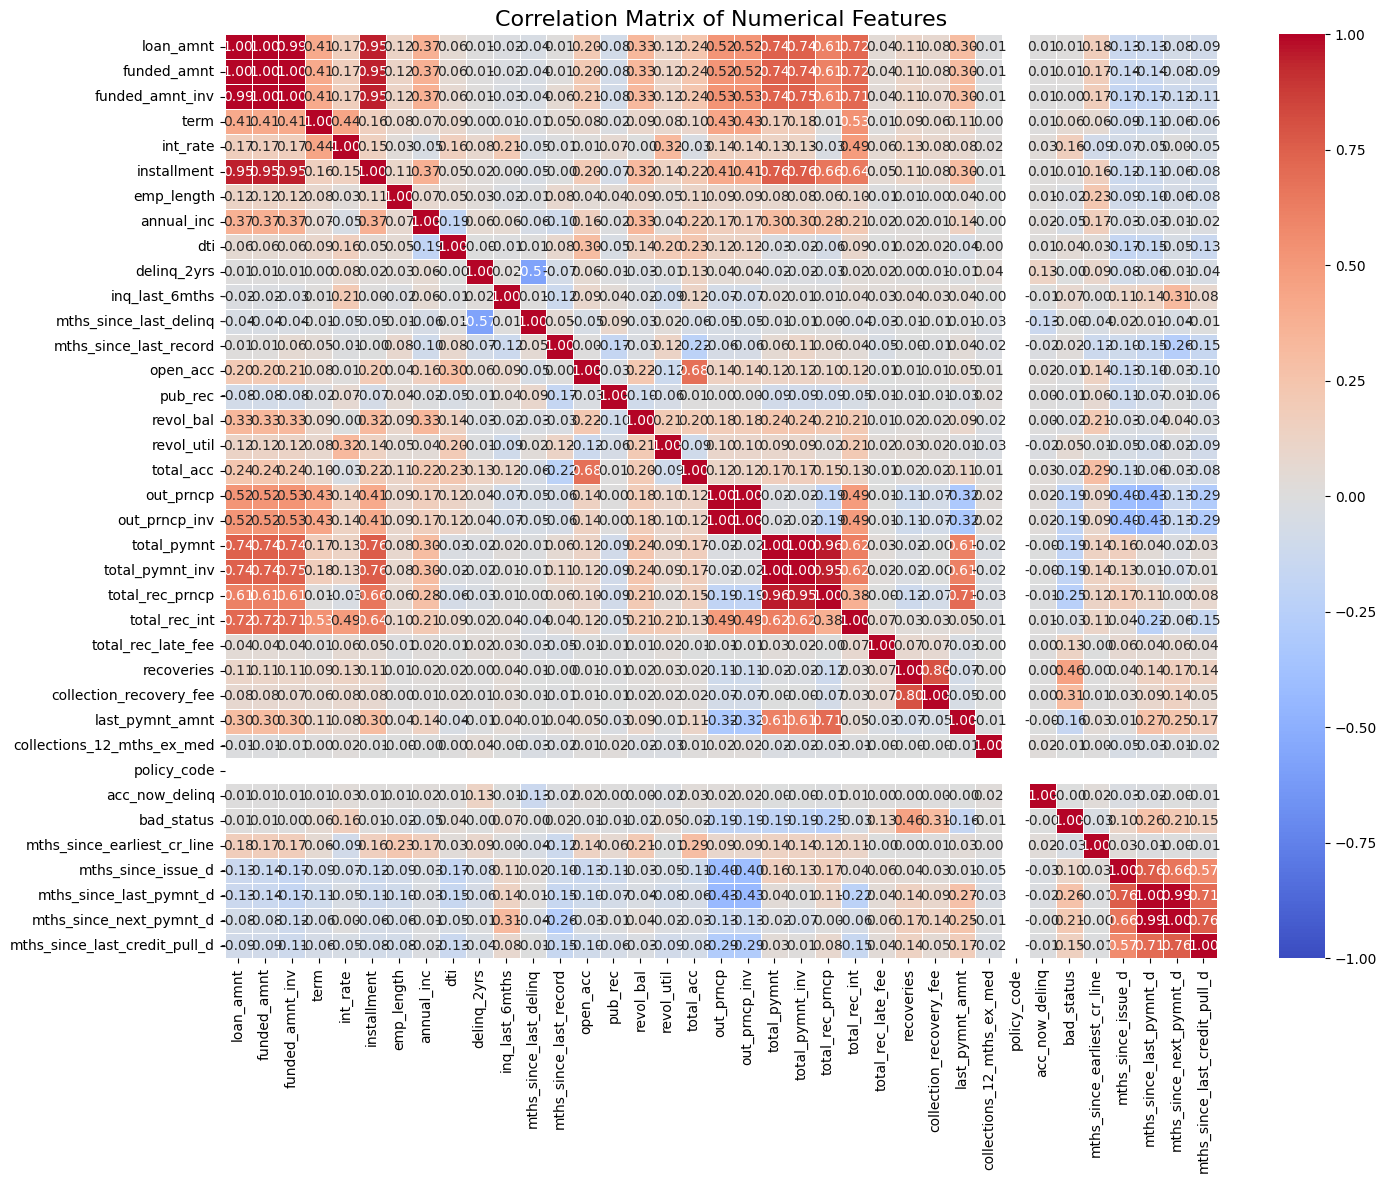

In [60]:
# Correlation Matrix

corr_matrix = numerical_df.corr()
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    center=0
)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()


#### Check Cardinality Data

In [61]:
categorical_df.nunique()

,0
grade,7
emp_title,205475
home_ownership,6
verification_status,3
pymnt_plan,2
purpose,14
title,63098
addr_state,50
initial_list_status,2
application_type,1


In [62]:
numerical_df.nunique()

,0
loan_amnt,1352
funded_amnt,1354
funded_amnt_inv,9854
term,2
int_rate,506
installment,55622
emp_length,10
annual_inc,31901
dti,3997
delinq_2yrs,24


In [63]:
df.drop(['policy_code'],axis=1, inplace=True)
df.shape

(466285, 46)

In [64]:
for col in categorical_df.columns.tolist():
    print('Distribusi nilai untuk fitur',col)
    print(df[col].value_counts(normalize=True) *100)


Distribusi nilai untuk fitur grade
grade
B    29.365946
C    26.870476
D    16.489486
A    16.056060
E     7.668486
F     2.837106
G     0.712440
Name: proportion, dtype: float64
Distribusi nilai untuk fitur emp_title
emp_title
Teacher                                 1.230690
Manager                                 1.011632
Registered Nurse                        0.527927
RN                                      0.502397
Supervisor                              0.448373
                                          ...   
berenfield  containers                  0.000228
harris rebar                            0.000228
sierra vista regional medical center    0.000228
County of San Dieigo                    0.000228
Landmark Earth Solutions, Inc.          0.000228
Name: proportion, Length: 205475, dtype: float64
Distribusi nilai untuk fitur home_ownership
home_ownership
MORTGAGE    50.586015
RENT        40.420129
OWN          8.943886
OTHER        0.039032
NONE         0.010723
ANY          0.

Nilai distribusi pada fitur pymnt_plan sagat bias, 99% termasuk ke nilai n dan sisanya y, maka dari itu fitur ini perlu dihapus agar tidak menyebabkan bias pada model

In [65]:
df.drop(['pymnt_plan'],axis=1, inplace=True)
df.shape

(466285, 45)

### UNIVARIATE ANALYSIS

In [66]:
# Cek kolom categorical yang tersisa
print(df.select_dtypes(include='object').columns.tolist())
print(f"Jumlah kolom categorical: {len(df.select_dtypes(include='object').columns)}")

['grade', 'emp_title', 'home_ownership', 'verification_status', 'purpose', 'title', 'addr_state', 'initial_list_status', 'application_type']
Jumlah kolom categorical: 9


In [67]:
categorical_df.nunique()

,0
grade,7
emp_title,205475
home_ownership,6
verification_status,3
pymnt_plan,2
purpose,14
title,63098
addr_state,50
initial_list_status,2
application_type,1


Fitur emp_title dan title memiliki banyak sekali nilai unik, perlu dihapus agar visualisai distribusi categorical data dapat berjalan

In [68]:
df.drop(['emp_title', 'title', 'application_type'], axis=1, inplace=True)


In [69]:
categorical_df = df.select_dtypes(include=['object']).columns
categorical_df

Index(['grade', 'home_ownership', 'verification_status', 'purpose',
       'addr_state', 'initial_list_status'],
      dtype='object')

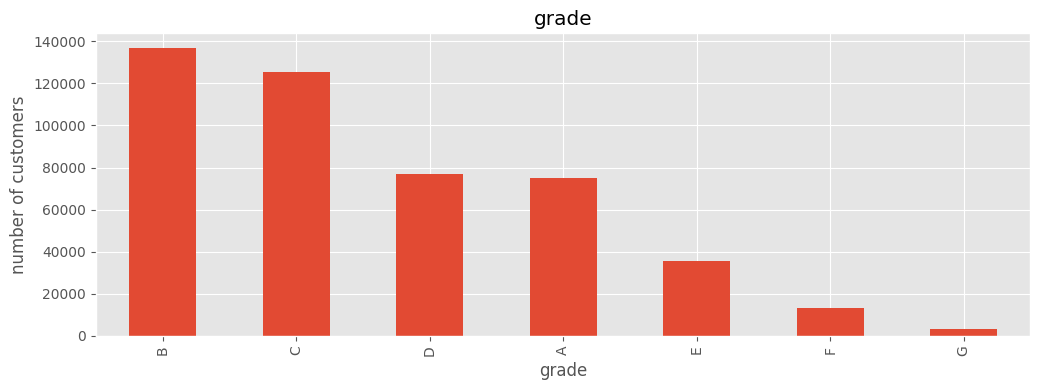

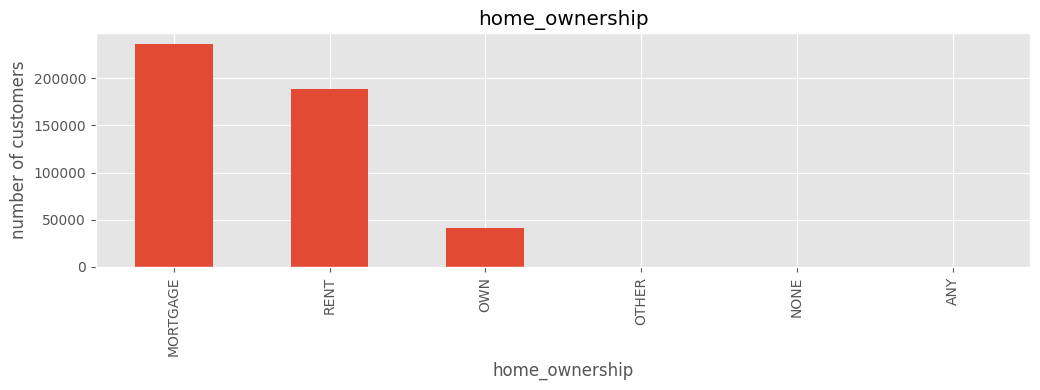

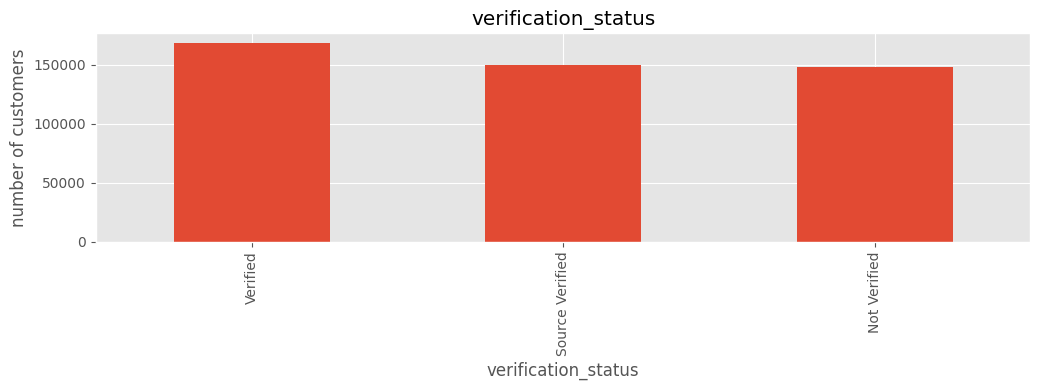

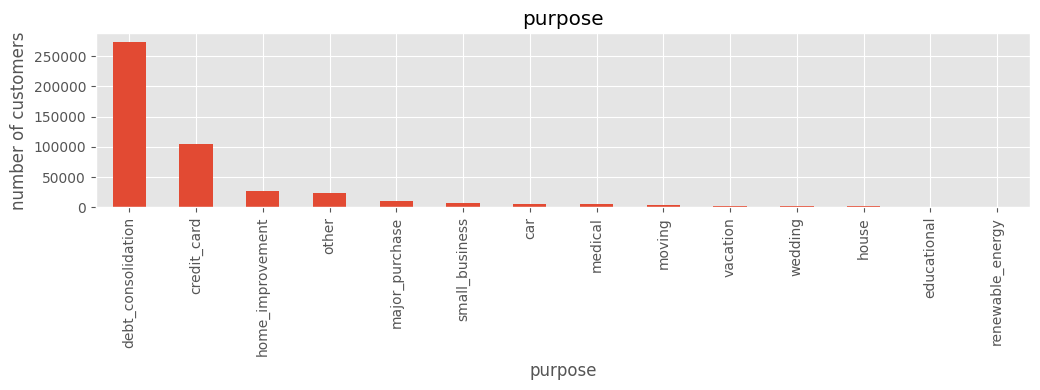

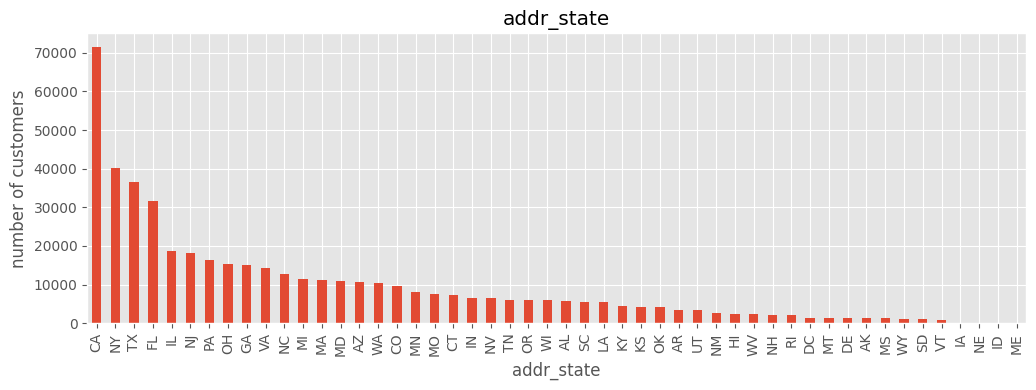

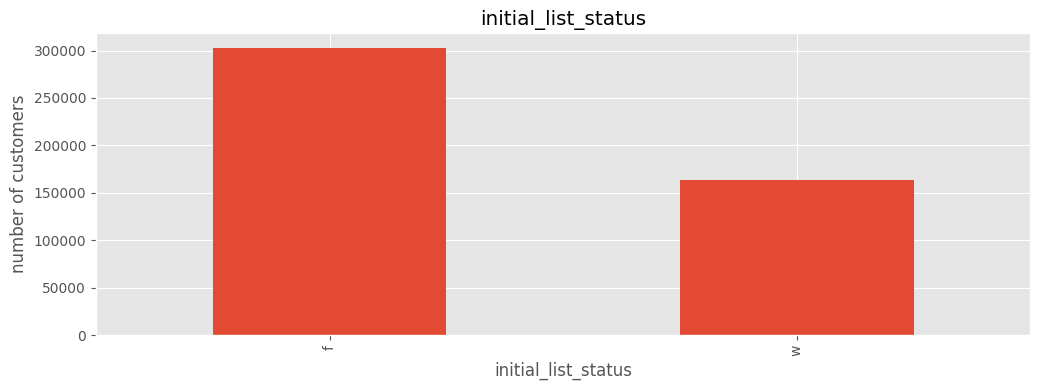

In [70]:
# Distribusi Categorical Data
plt.style.use("ggplot")

for column in categorical_df:
    plt.figure(figsize=(20, 4))
    plt.subplot(121)
    df[column].value_counts().plot(kind="bar")
    plt.xlabel(column)
    plt.ylabel("number of customers")
    plt.title(column)
    plt.tight_layout()
    plt.show()

In [71]:
numerical_df = df.select_dtypes(include=np.number)
numerical_df

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,acc_now_delinq,bad_status,mths_since_earliest_cr_line,mths_since_issue_d,mths_since_last_pymnt_d,mths_since_next_pymnt_d,mths_since_last_credit_pull_d
0,5000,5000,4975.0,36.0,10.65,162.87,10.0,24000.0,27.65,0.0,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,0.00,0.00,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,171.62,0.0,0.0,0,395.0,72.0,35.0,NaN,23.0
1,2500,2500,2500.0,60.0,15.27,59.83,1.0,30000.0,1.00,0.0,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,0.00,0.00,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,119.66,0.0,0.0,1,224.0,72.0,56.0,NaN,51.0
2,2400,2400,2400.0,36.0,15.96,84.33,10.0,12252.0,8.72,0.0,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,0.00,0.00,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,649.91,0.0,0.0,0,193.0,72.0,42.0,NaN,23.0
3,10000,10000,10000.0,36.0,13.49,339.31,10.0,49200.0,20.00,0.0,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,0.00,0.00,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,357.48,0.0,0.0,0,262.0,72.0,35.0,NaN,35.0
4,3000,3000,3000.0,60.0,12.69,67.79,1.0,80000.0,17.94,0.0,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,766.90,766.90,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,67.79,0.0,0.0,0,263.0,72.0,23.0,22.0,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,18400,18400,18400.0,60.0,14.47,432.64,4.0,110000.0,19.85,0.0,2.0,NaN,NaN,18.0,0.0,23208,77.6,36.0,12574.00,12574.00,10383.360000,10383.36,5826.00,4557.36,0.00,0.00,0.00,432.64,0.0,0.0,0,176.0,47.0,23.0,22.0,23.0
466281,22000,22000,22000.0,60.0,19.97,582.50,10.0,78000.0,18.45,0.0,5.0,NaN,116.0,18.0,1.0,18238,46.3,30.0,0.00,0.00,4677.920000,4677.92,1837.04,2840.88,0.00,0.00,0.00,17.50,0.0,0.0,1,246.0,47.0,36.0,NaN,23.0
466282,20700,20700,20700.0,60.0,16.99,514.34,7.0,46000.0,25.65,0.0,2.0,65.0,NaN,18.0,0.0,6688,51.1,43.0,14428.31,14428.31,12343.980000,12343.98,6271.69,6072.29,0.00,0.00,0.00,514.34,0.0,0.0,0,192.0,47.0,23.0,22.0,24.0
466283,2000,2000,2000.0,36.0,7.90,62.59,3.0,83000.0,5.39,3.0,1.0,13.0,NaN,21.0,0.0,11404,21.5,27.0,0.00,0.00,2126.579838,2126.58,2000.00,126.58,0.00,0.00,0.00,1500.68,0.0,0.0,0,178.0,47.0,36.0,NaN,32.0


In [72]:
numerical_df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,acc_now_delinq,bad_status,mths_since_earliest_cr_line,mths_since_issue_d,mths_since_last_pymnt_d,mths_since_next_pymnt_d,mths_since_last_credit_pull_d
0,5000,5000,4975.0,36.0,10.65,162.87,10.0,24000.0,27.65,0.0,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,171.62,0.0,0.0,0,395.0,72.0,35.0,NaN,23.0
1,2500,2500,2500.0,60.0,15.27,59.83,1.0,30000.0,1.00,0.0,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,119.66,0.0,0.0,1,224.0,72.0,56.0,NaN,51.0
2,2400,2400,2400.0,36.0,15.96,84.33,10.0,12252.0,8.72,0.0,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,649.91,0.0,0.0,0,193.0,72.0,42.0,NaN,23.0
3,10000,10000,10000.0,36.0,13.49,339.31,10.0,49200.0,20.00,0.0,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,357.48,0.0,0.0,0,262.0,72.0,35.0,NaN,35.0
4,3000,3000,3000.0,60.0,12.69,67.79,1.0,80000.0,17.94,0.0,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,67.79,0.0,0.0,0,263.0,72.0,23.0,22.0,23.0


Ringkasan statistik loan_amnt
Rata-rata: 14317.277577018347
Median: 12000.0
Modus: 10000
Standar Deviasi: 8286.509164150219
Ringkasan statistik funded_amnt
Rata-rata: 14291.80104442562
Median: 12000.0
Modus: 10000
Standar Deviasi: 8274.371299990617
Ringkasan statistik funded_amnt_inv
Rata-rata: 14222.32988821466
Median: 12000.0
Modus: 10000.0
Standar Deviasi: 8297.637788271766
Ringkasan statistik term
Rata-rata: 42.6053336478763
Median: 36.0
Modus: 36.0
Standar Deviasi: 10.719040132388619
Ringkasan statistik int_rate
Rata-rata: 13.829235939393294
Median: 13.66
Modus: 12.99
Standar Deviasi: 4.357586582506935
Ringkasan statistik installment
Rata-rata: 432.06120074632474
Median: 379.89
Modus: 327.34
Standar Deviasi: 243.48554986429568
Ringkasan statistik emp_length
Rata-rata: 6.074773680203559
Median: 6.0
Modus: 10.0
Standar Deviasi: 3.5005737256229943
Ringkasan statistik annual_inc
Rata-rata: 73277.38147046522
Median: 63000.0
Modus: 60000.0
Standar Deviasi: 54963.56865386743
Ringkasan st

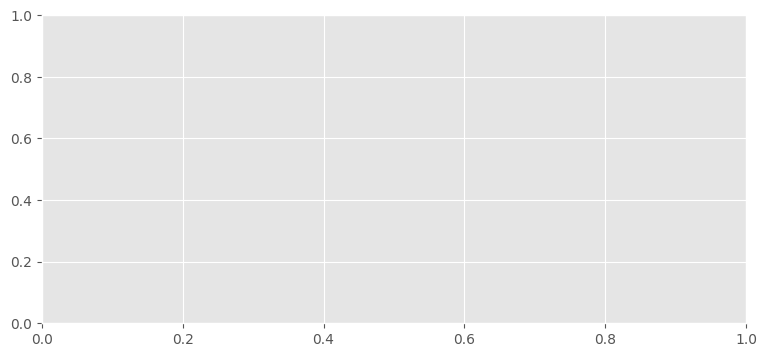

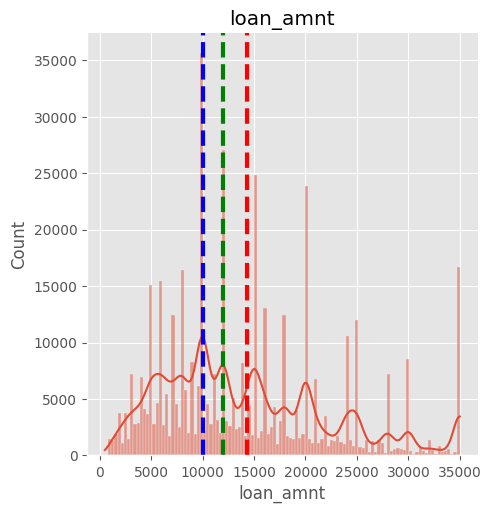

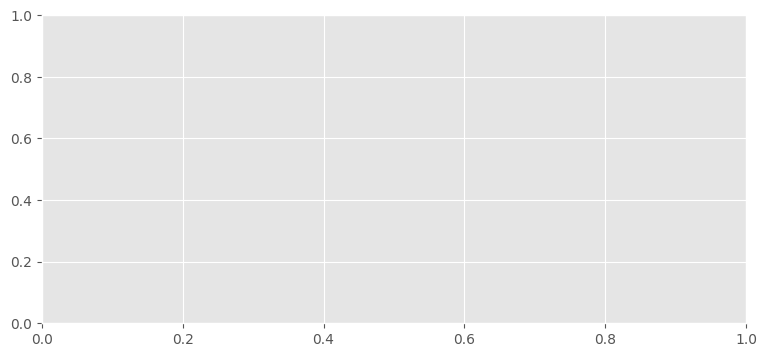

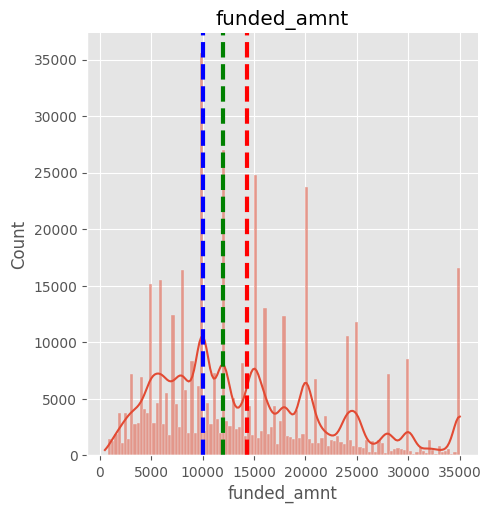

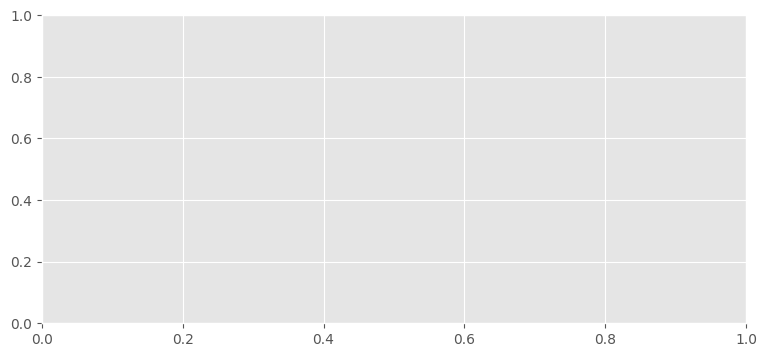

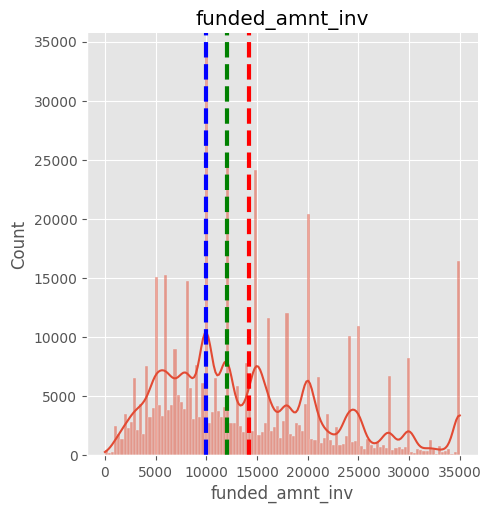

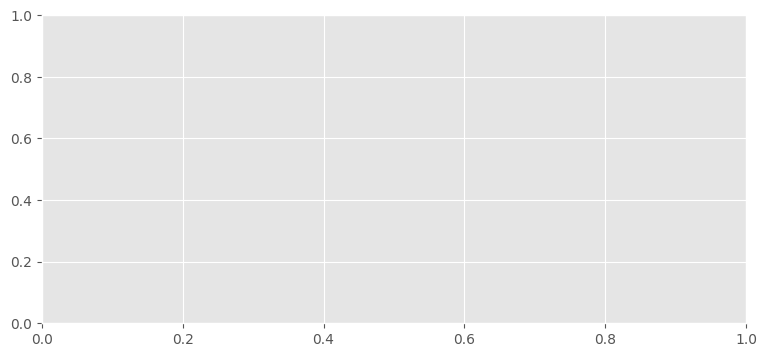

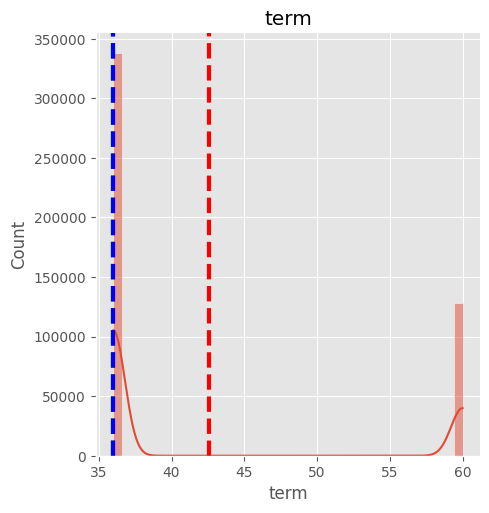

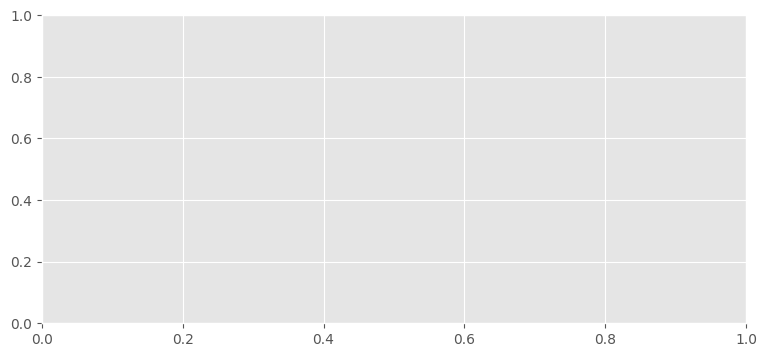

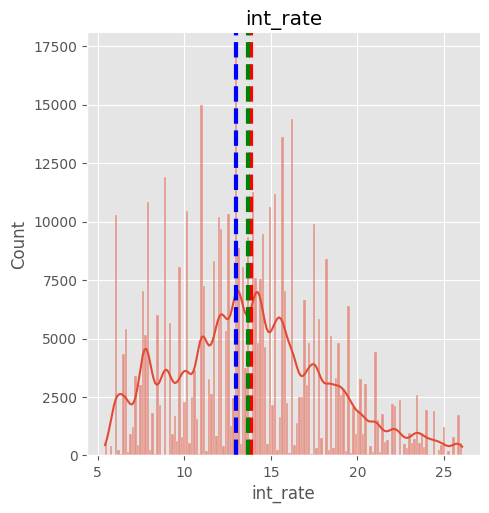

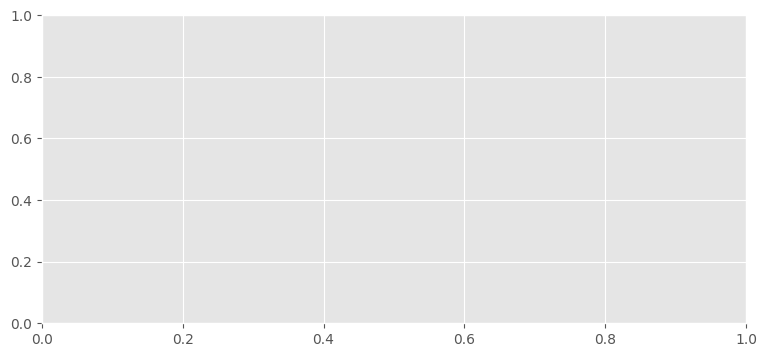

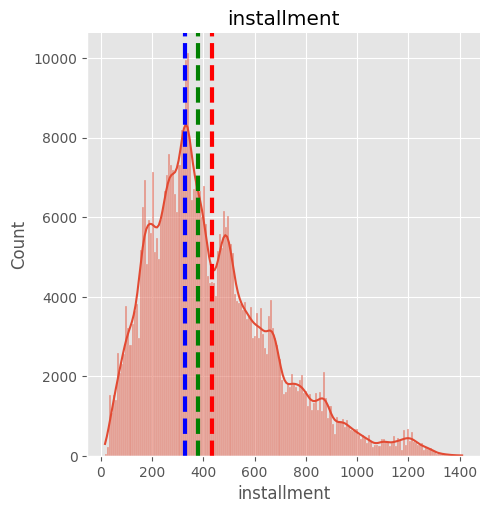

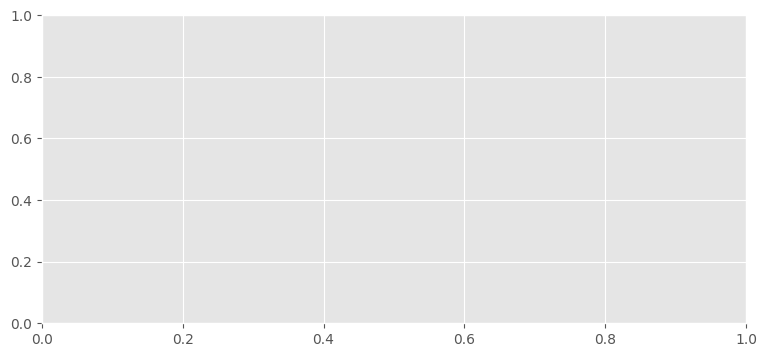

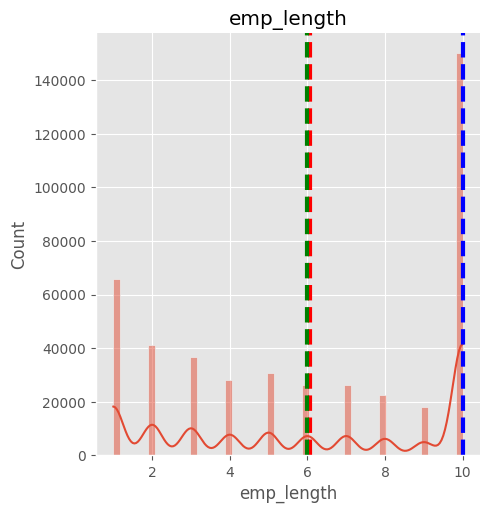

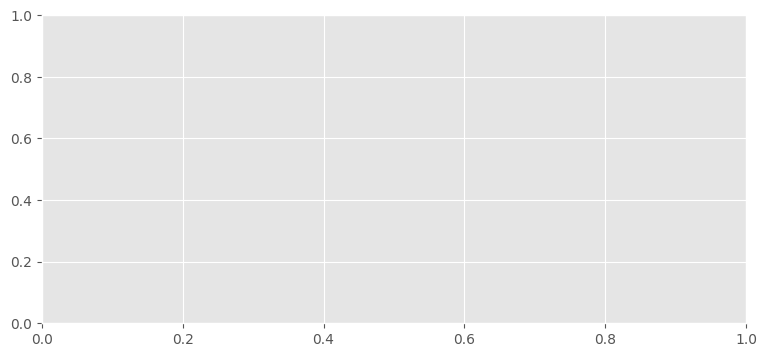

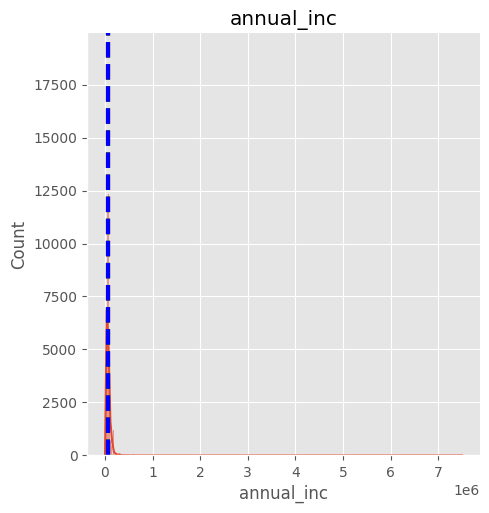

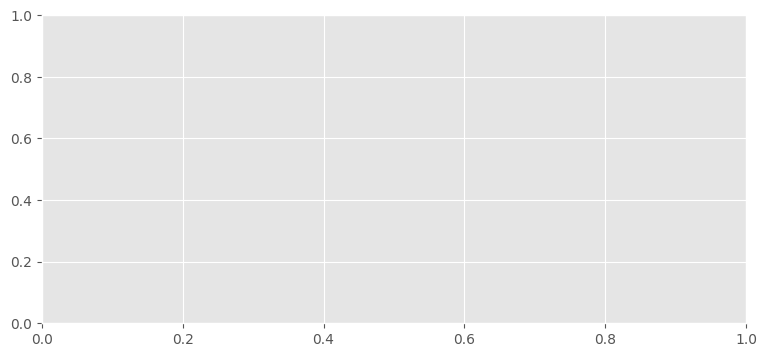

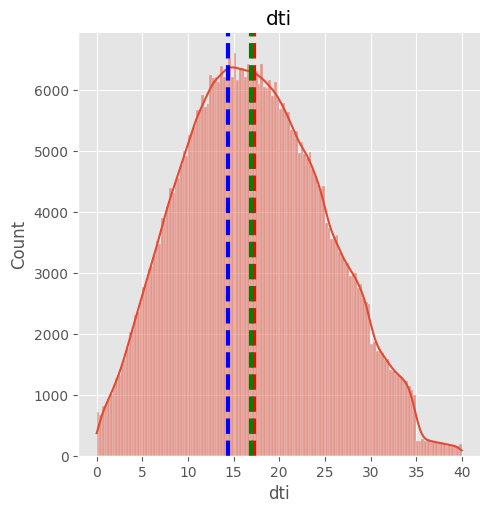

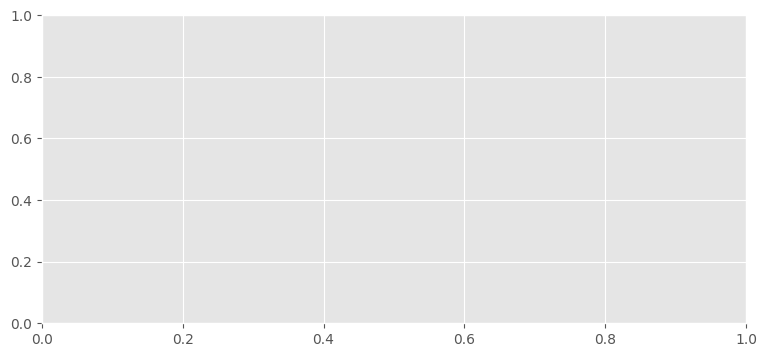

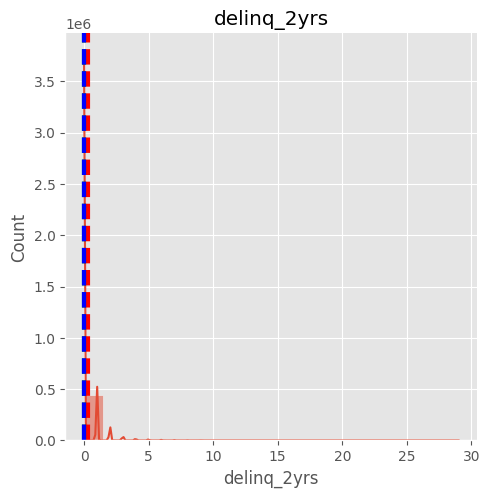

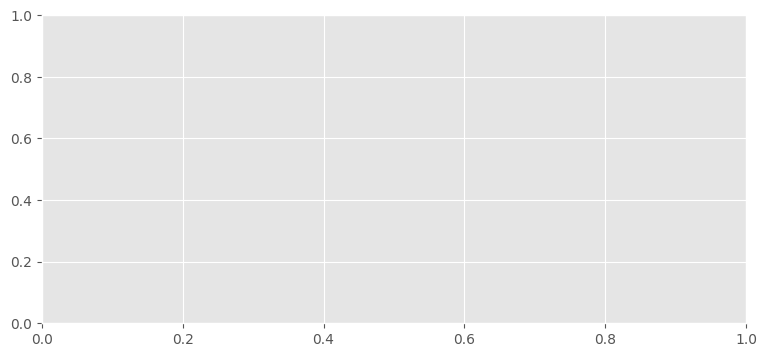

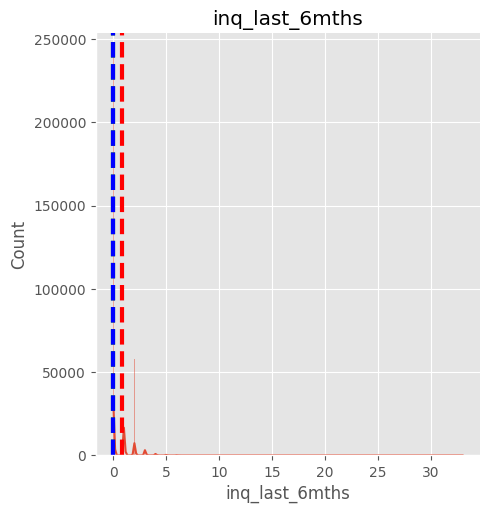

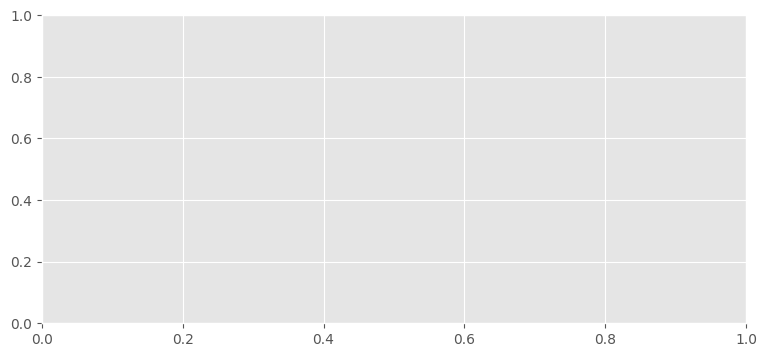

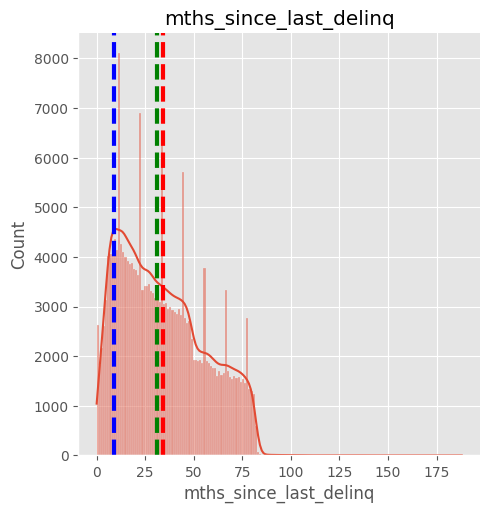

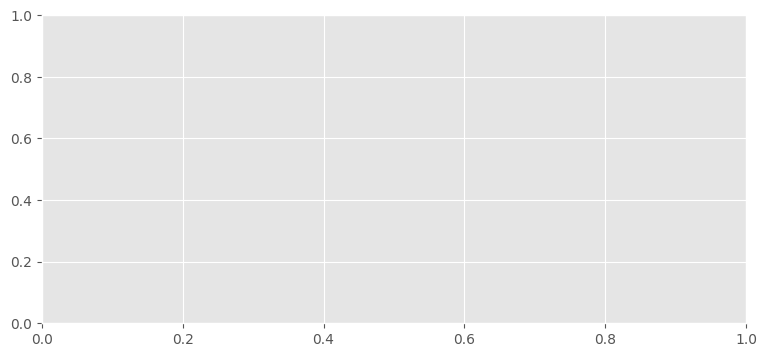

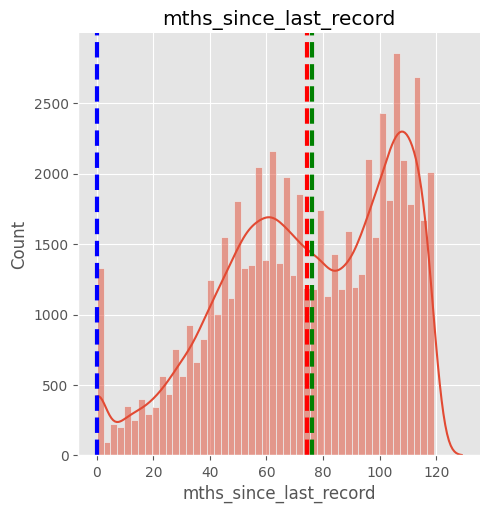

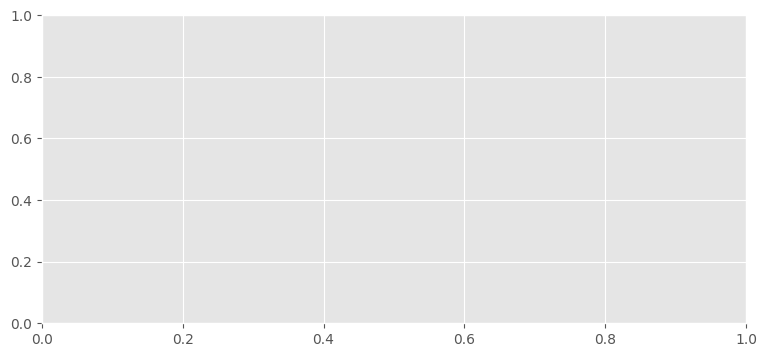

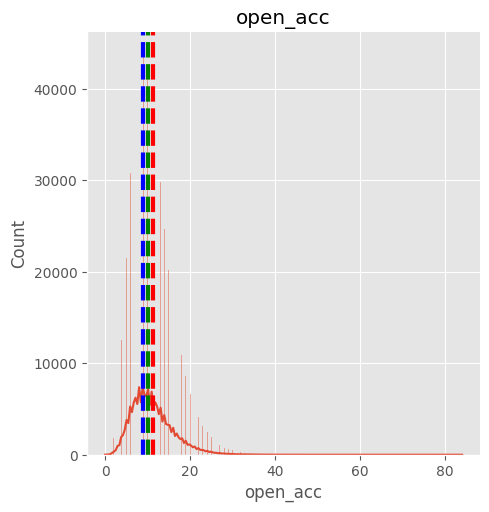

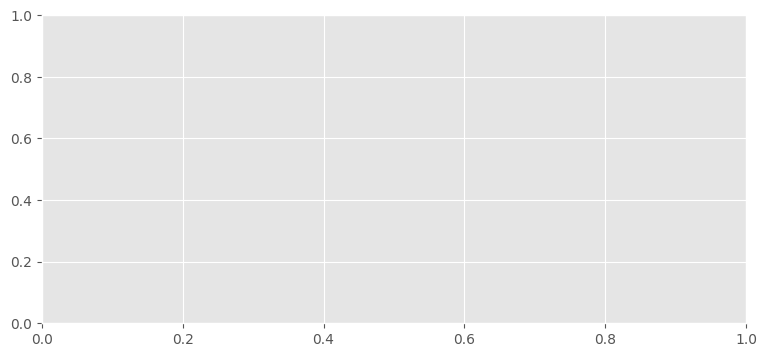

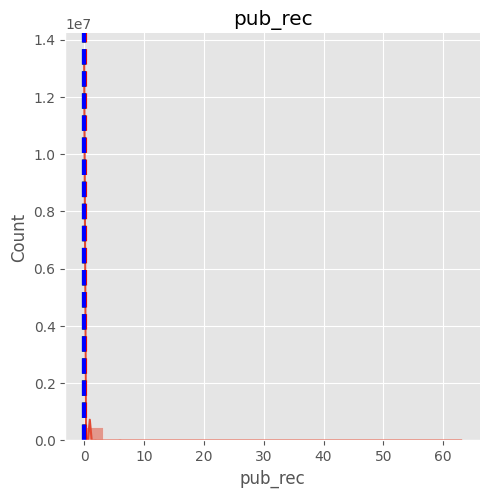

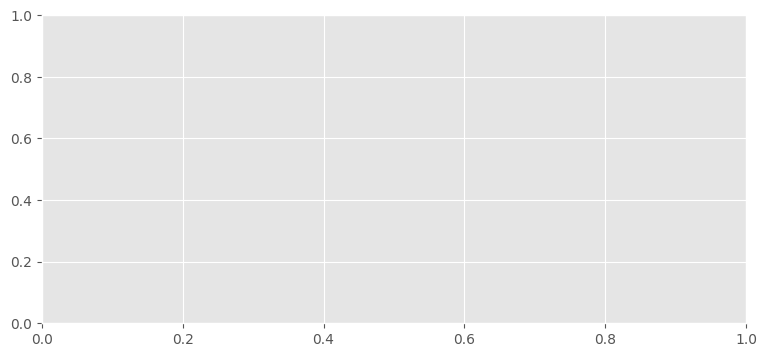

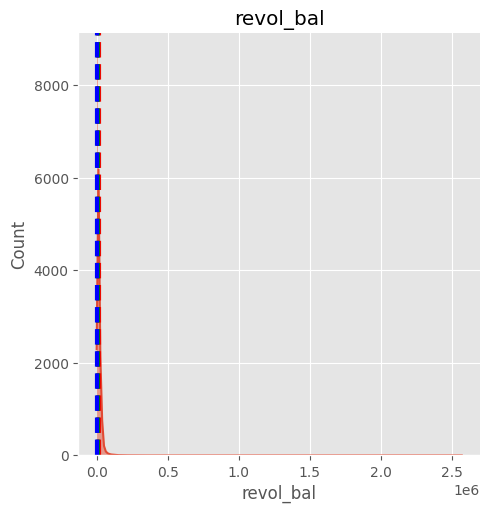

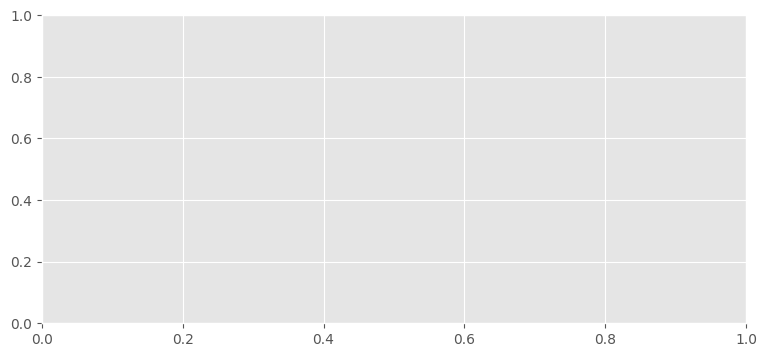

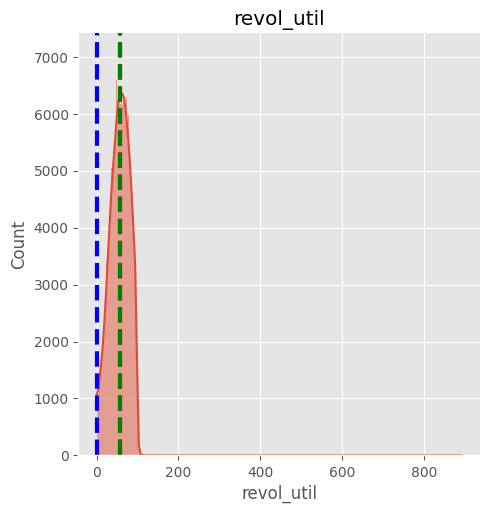

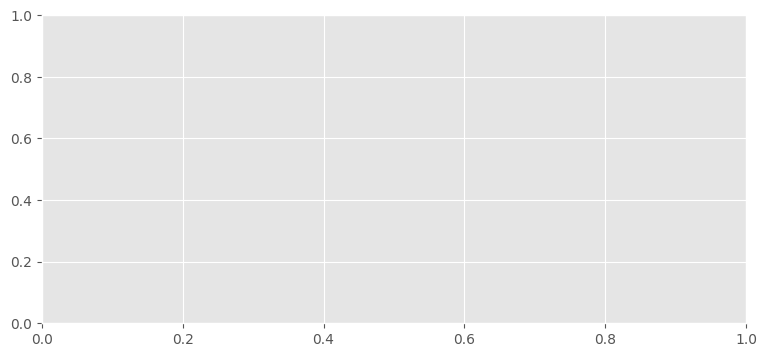

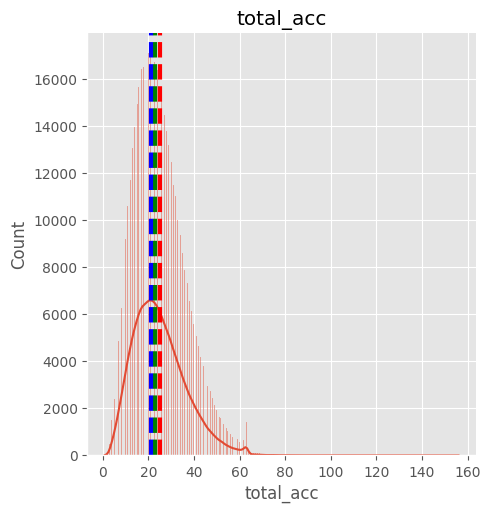

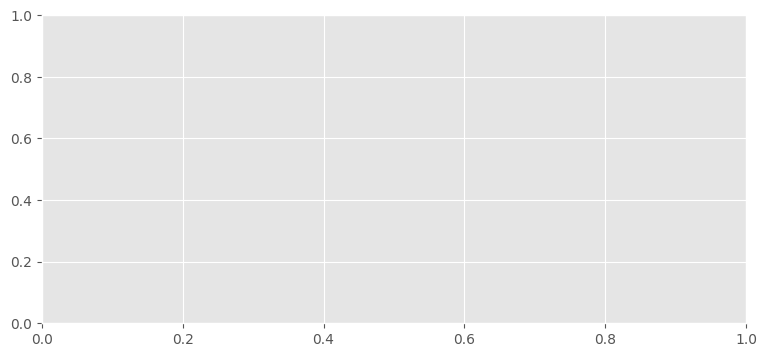

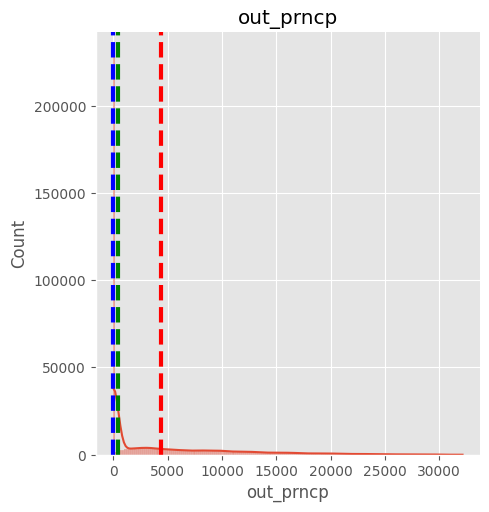

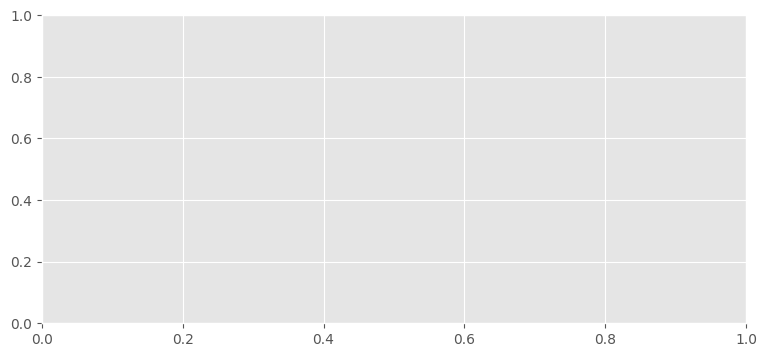

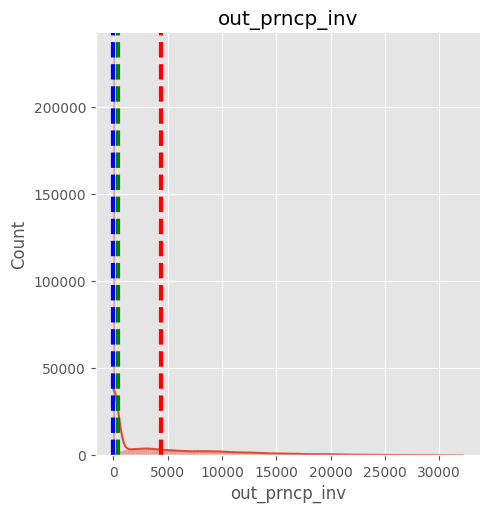

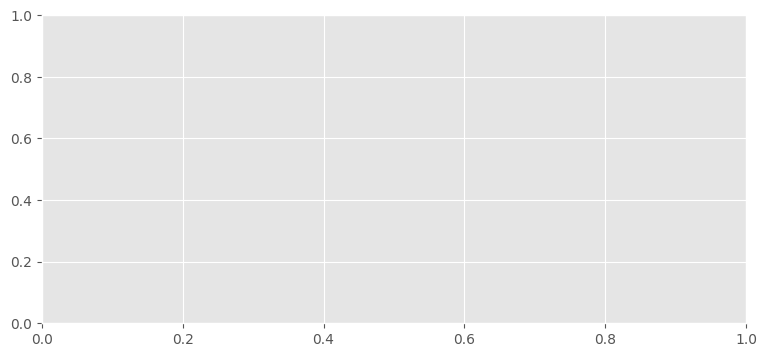

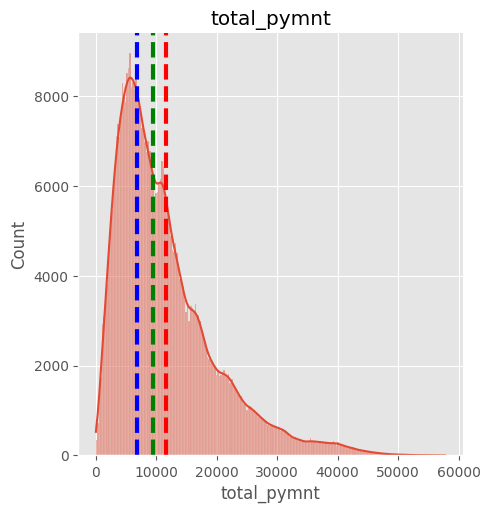

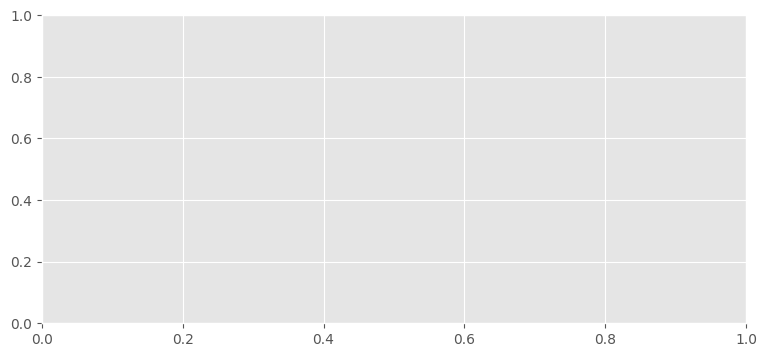

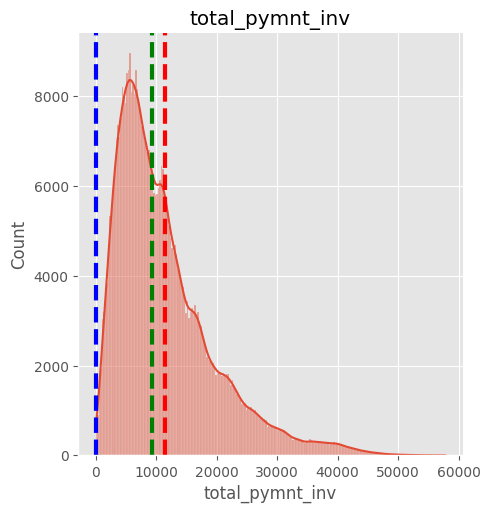

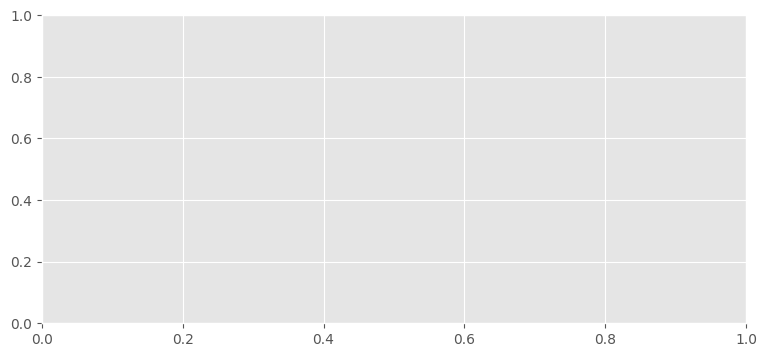

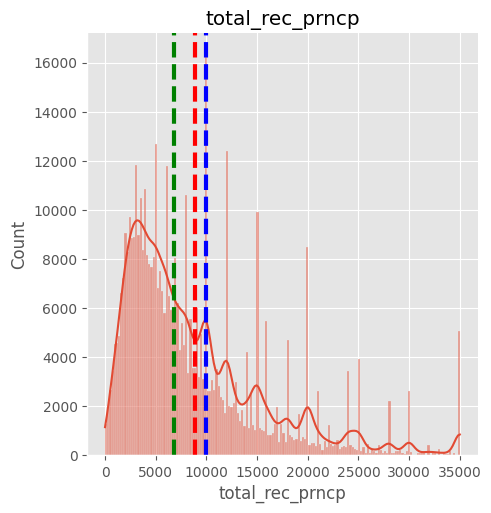

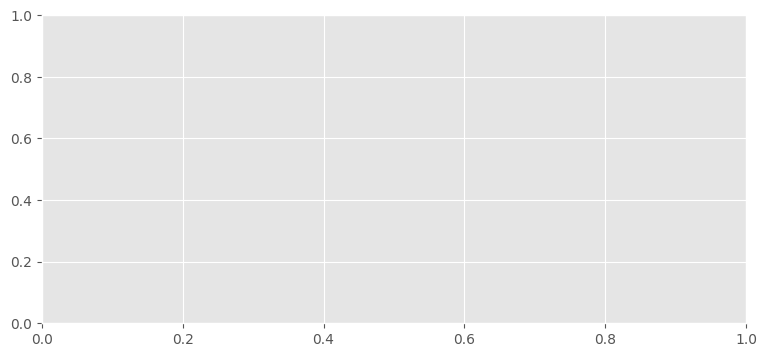

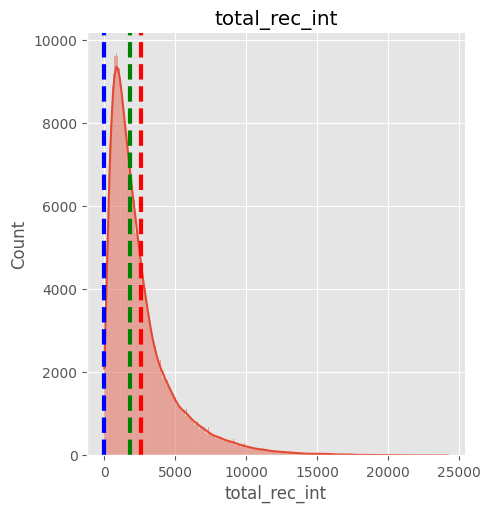

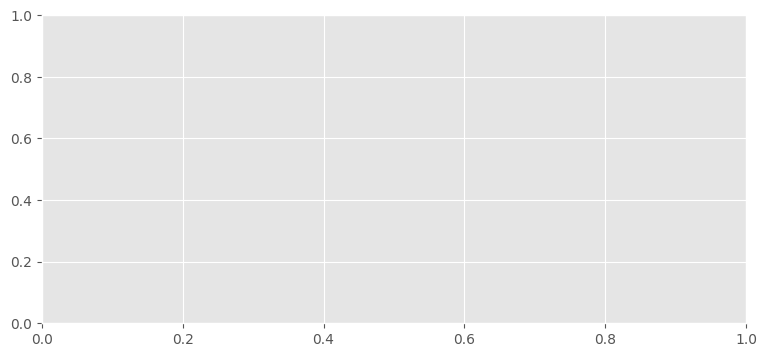

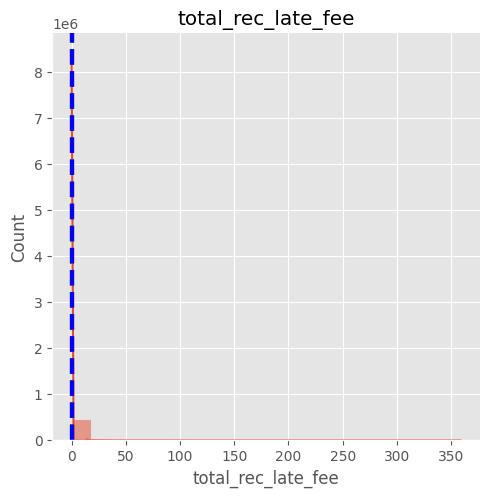

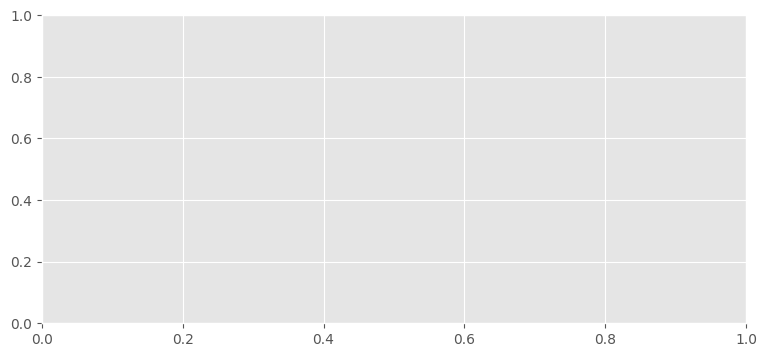

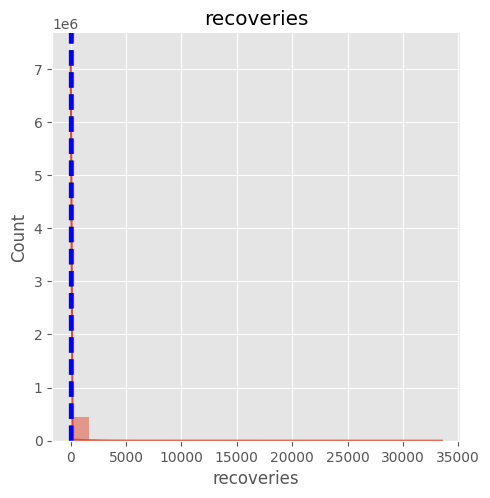

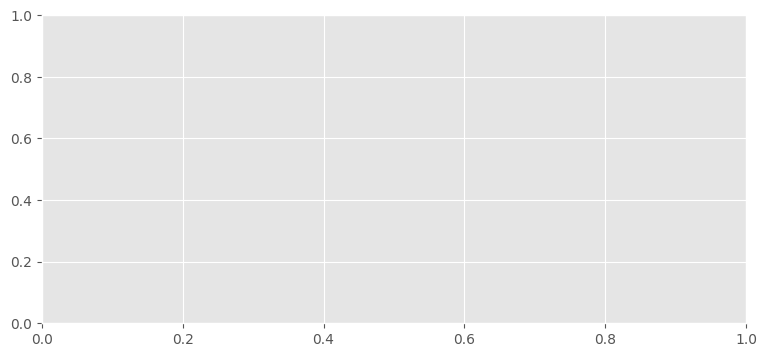

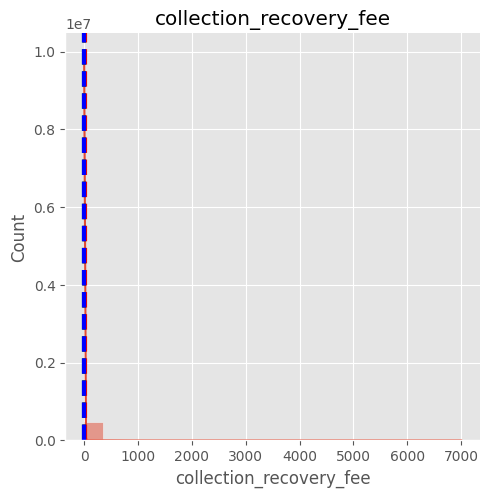

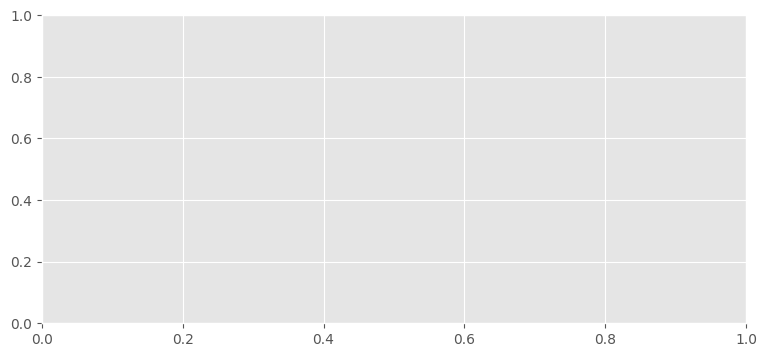

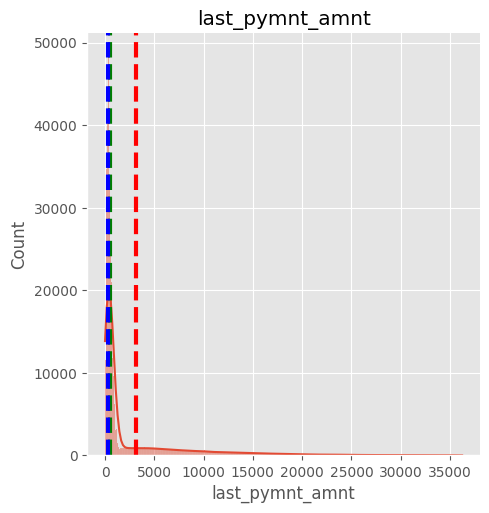

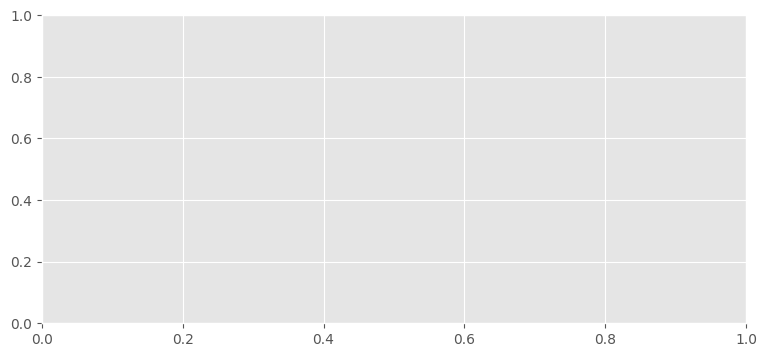

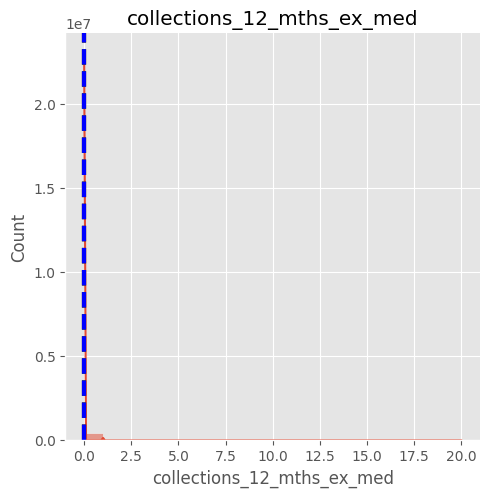

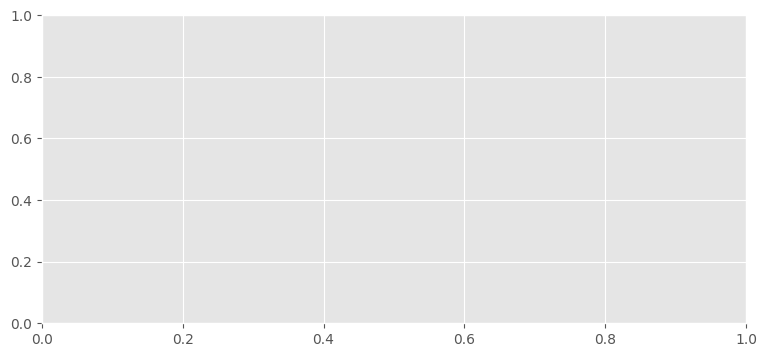

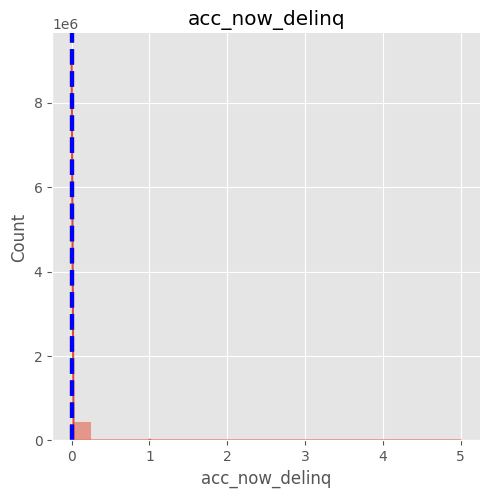

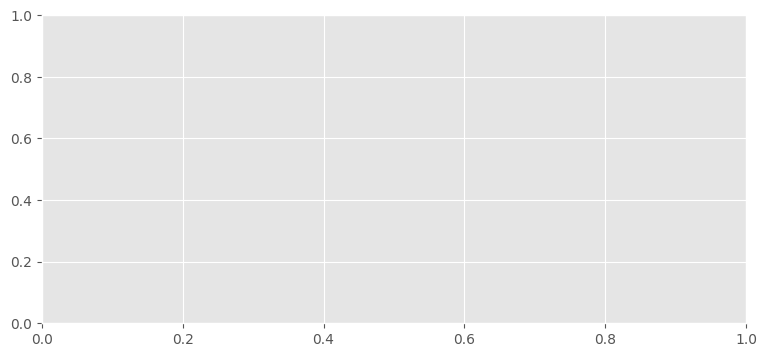

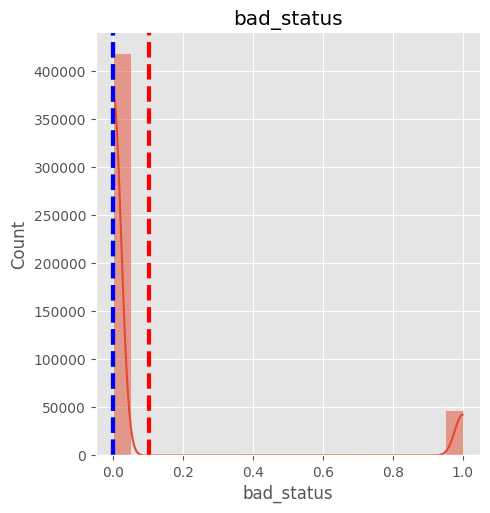

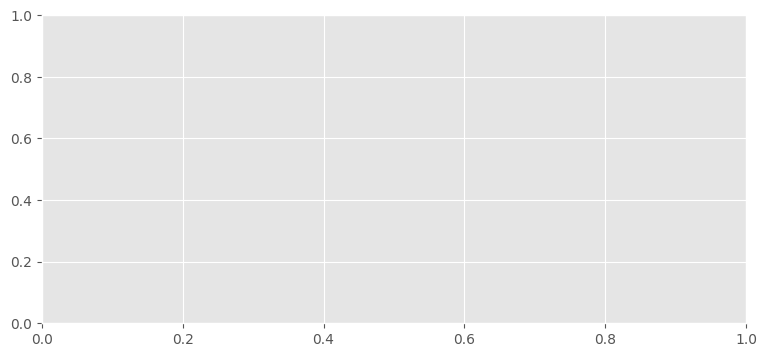

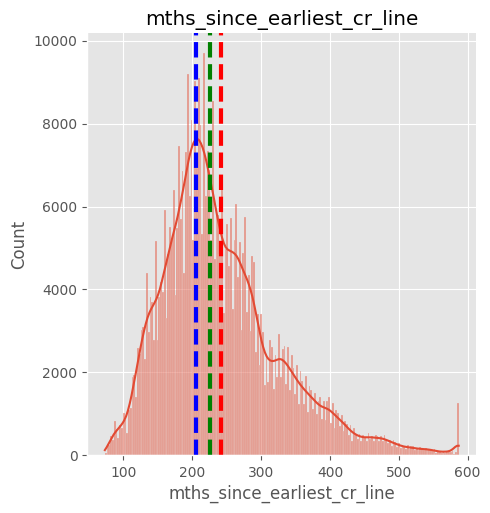

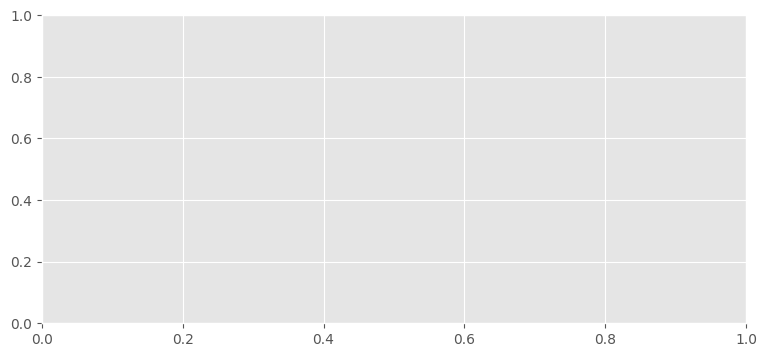

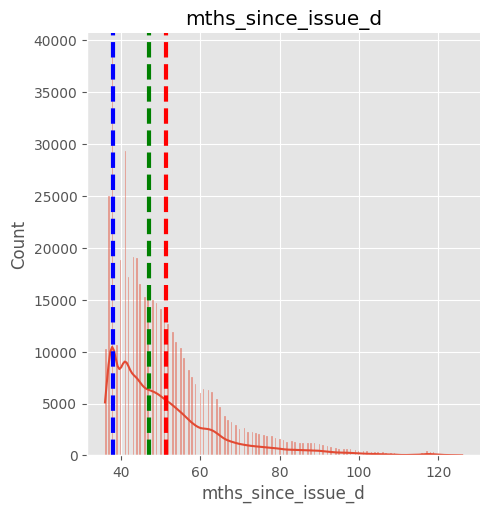

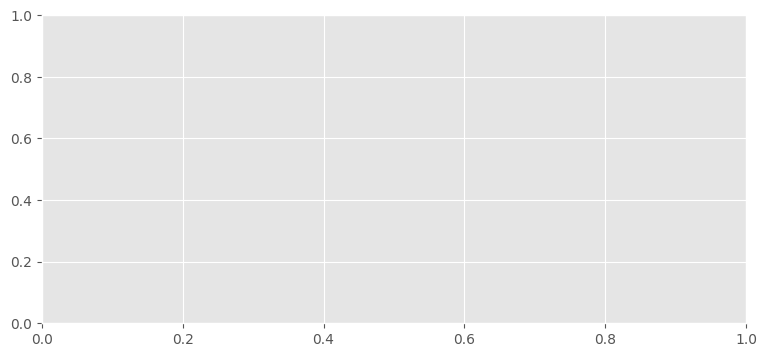

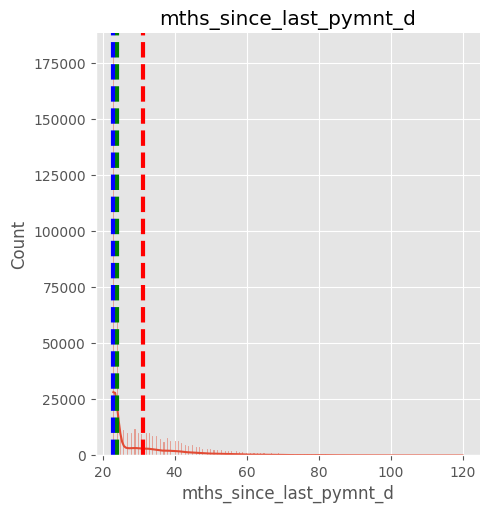

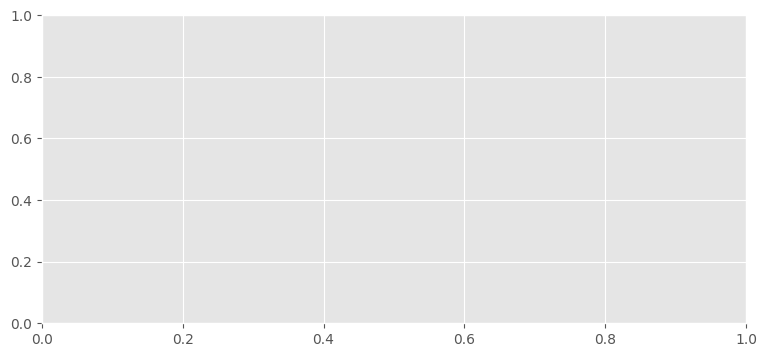

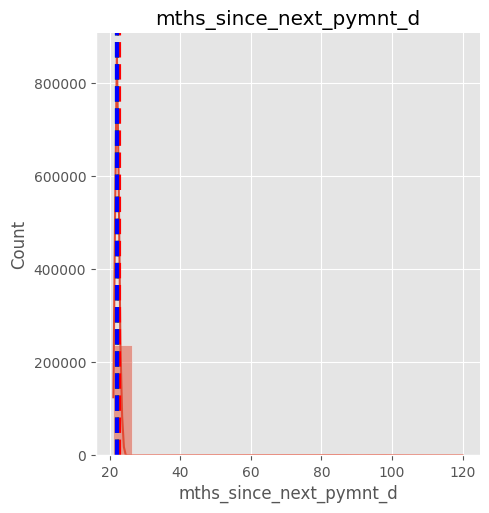

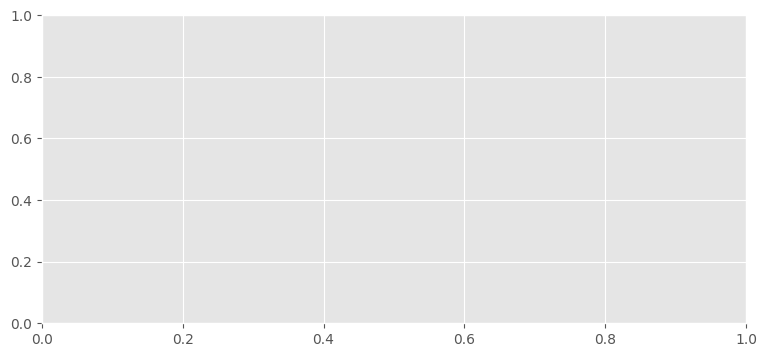

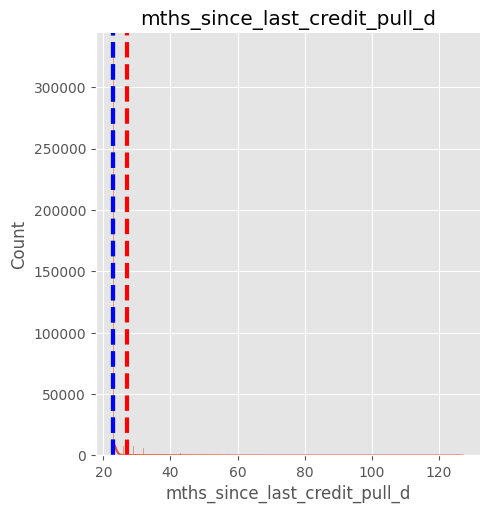

In [73]:
plt.style.use('ggplot')
for column in numerical_df.columns.tolist():
  average = df[column].mean()
  median = df[column].median()
  mode = df[column].mode().iloc[0]
  std = df[column].std()


  plt.figure(figsize=(20,4))
  plt.subplot(121)
  sns.displot(df[column], kde=True)
  plt.axvline(average, color='red', linestyle='dashed', linewidth=3, label='mean')
  plt.axvline(median, color='green', linestyle='dashed', linewidth=3, label='median')
  plt.axvline(mode, color='blue', linestyle='dashed', linewidth=3, label='mode')
  plt.title(column)

  print('Ringkasan statistik {columns}'.format(columns=column))
  print('Rata-rata: {average}'.format(average=average))
  print('Median: {median}'.format(median=median))
  print('Modus: {mode}'.format(mode=mode))
  print('Standar Deviasi: {std}'.format(std=std))


### BIVARIATE ANALYSIS

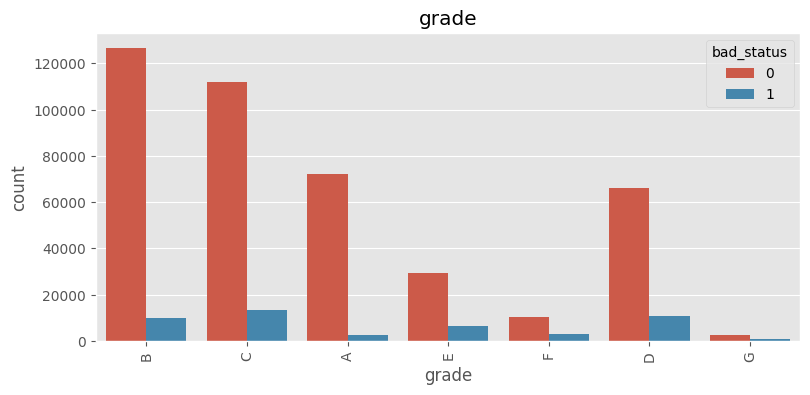

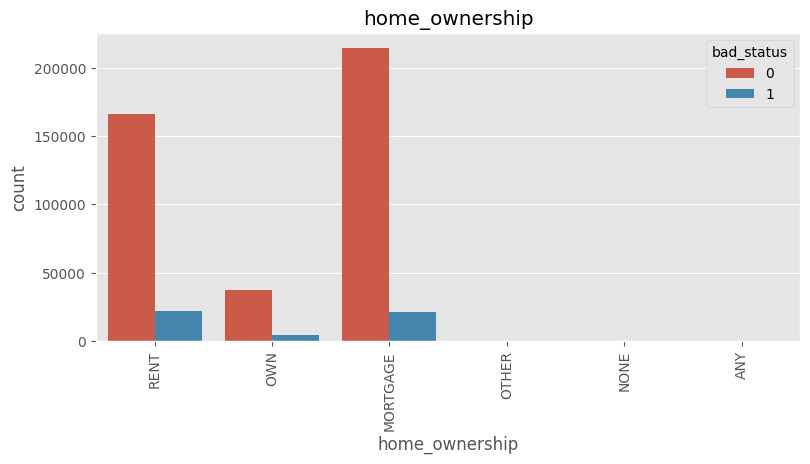

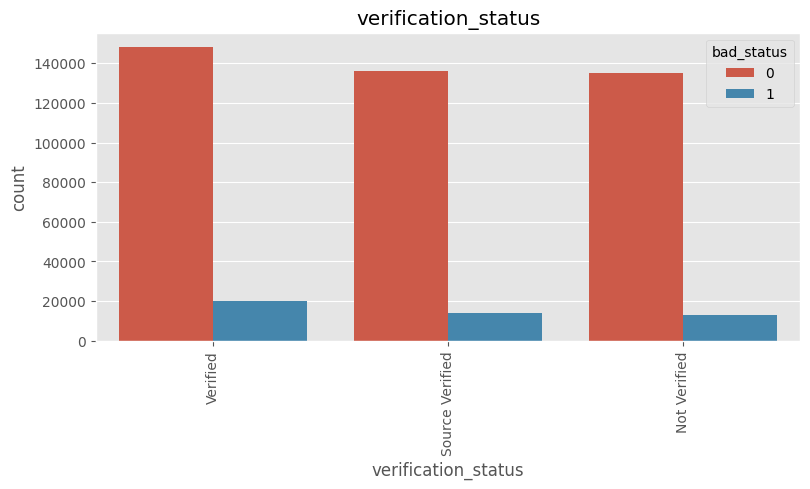

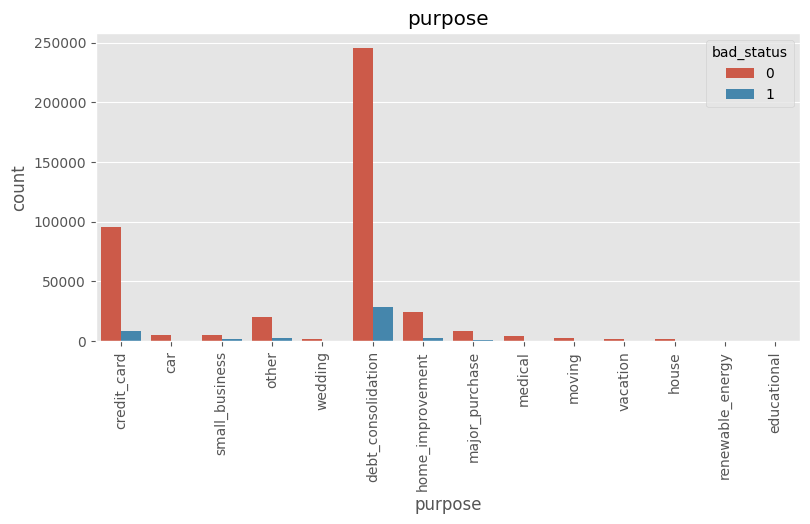

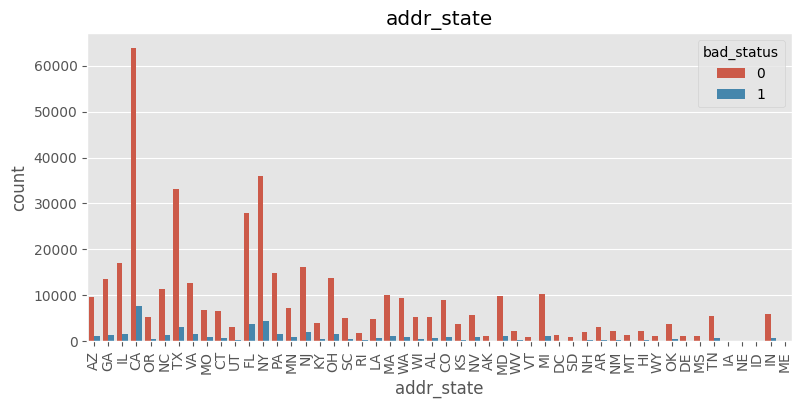

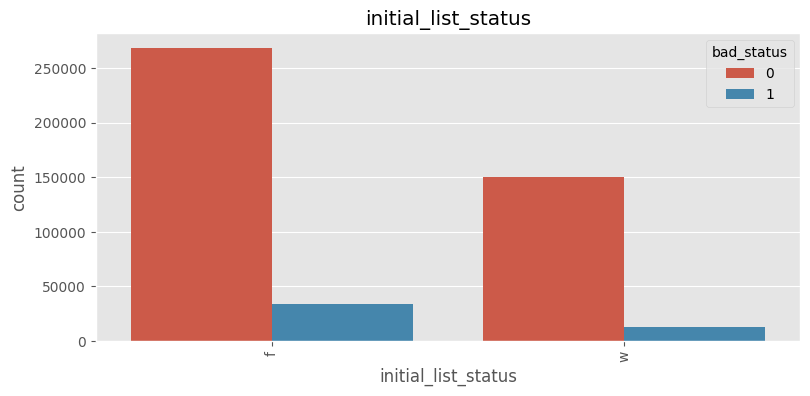

In [74]:
plt.style.use('ggplot')
for column in categorical_df:
  plt.figure(figsize=(20,4))
  plt.subplot(121)
  sns.countplot(x=column, hue='bad_status', data=df)
  plt.title(column)
  plt.xticks(rotation=90)

In [75]:
missing_values_pct = df.isnull().sum() * 100 / df.shape[0]

missing_values = missing_values_pct[missing_values_pct > 0].sort_values(ascending=False)
print('Presentase nilai yang hilang untuk setiap fitur:')
print(missing_values)

Presentase nilai yang hilang untuk setiap fitur:
mths_since_last_record           86.566585
mths_since_last_delinq           53.690554
mths_since_next_pymnt_d          48.728567
emp_length                        4.505399
mths_since_last_pymnt_d           0.080637
revol_util                        0.072917
collections_12_mths_ex_med        0.031097
mths_since_last_credit_pull_d     0.009007
delinq_2yrs                       0.006219
pub_rec                           0.006219
inq_last_6mths                    0.006219
open_acc                          0.006219
acc_now_delinq                    0.006219
total_acc                         0.006219
mths_since_earliest_cr_line       0.006219
annual_inc                        0.000858
dtype: float64


Ditemukan missing values lebih dari 80%, yang artinya sangat banyak dan tidak bisa digunakan, sehaingga perlu di drop

In [76]:
df.drop('mths_since_last_record',axis=1, inplace=True)

#### Data Imputation

In [77]:
df.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'initial_list_status',
       'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_amnt',
       'collections_12_mths_ex_med', 'acc_now_delinq', 'bad_status',
       'mths_since_earliest_cr_line', 'mths_since_issue_d',
       'mths_since_last_pymnt_d', 'mths_since_next_pymnt_d',
       'mths_since_last_credit_pull_d'],
      dtype='object')

In [78]:
df['annual_inc'].fillna(df['annual_inc'].median(), inplace=True)
df['acc_now_delinq'].fillna(0, inplace=True)
df['total_acc'].fillna(0, inplace=True)
df['pub_rec' ]. fillna(0, inplace=True)
df['open_acc'].fillna(0, inplace=True)
df['inq_last_6mths']. fillna(0, inplace=True)
df['delinq_2yrs'].fillna(0, inplace=True)
df['collections_12_mths_ex_med'].fillna(0, inplace=True)
df['revol_util']. fillna(0, inplace=True)
df['emp_length'].fillna(0, inplace=True)
df['mths_since_last_delinq']. fillna(-1, inplace=True)
df['mths_since_next_pymnt_d'].fillna(-1, inplace=True)
df['mths_since_last_pymnt_d'].fillna(df['mths_since_last_pymnt_d'].median(), inplace=True)
df['mths_since_last_credit_pull_d'].fillna(df['mths_since_last_credit_pull_d'].median(), inplace=True)
df['mths_since_earliest_cr_line'].fillna(df['mths_since_earliest_cr_line'].median(), inplace=True)


### LABEL ENCODING

In [79]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in categorical_df:
  df[column] = le.fit_transform(df[column])

df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,acc_now_delinq,bad_status,mths_since_earliest_cr_line,mths_since_issue_d,mths_since_last_pymnt_d,mths_since_next_pymnt_d,mths_since_last_credit_pull_d
0,5000,5000,4975.0,36.0,10.65,162.87,1,10.0,5,24000.0,2,1,3,27.65,0.0,1.0,-1.0,3.0,0.0,13648,83.7,9.0,0,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,171.62,0.0,0.0,0,395.0,72.0,35.0,-1.0,23.0
1,2500,2500,2500.0,60.0,15.27,59.83,2,1.0,5,30000.0,1,0,10,1.00,0.0,5.0,-1.0,3.0,0.0,1687,9.4,4.0,0,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,119.66,0.0,0.0,1,224.0,72.0,56.0,-1.0,51.0
2,2400,2400,2400.0,36.0,15.96,84.33,2,10.0,5,12252.0,0,11,14,8.72,0.0,2.0,-1.0,2.0,0.0,2956,98.5,10.0,0,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,649.91,0.0,0.0,0,193.0,72.0,42.0,-1.0,23.0
3,10000,10000,10000.0,36.0,13.49,339.31,2,10.0,5,49200.0,1,9,4,20.00,0.0,1.0,35.0,10.0,0.0,5598,21.0,37.0,0,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,357.48,0.0,0.0,0,262.0,72.0,35.0,-1.0,35.0
4,3000,3000,3000.0,60.0,12.69,67.79,1,1.0,5,80000.0,1,9,36,17.94,0.0,0.0,38.0,15.0,0.0,27783,53.9,38.0,0,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,67.79,0.0,0.0,0,263.0,72.0,23.0,22.0,23.0


### HANDLING IMBALANCE DATA

In [80]:
X = df.drop('bad_status', axis=1)
y = df['bad_status']

In [81]:
y.value_counts()

,count
bad_status,
0,419071
1,47214


Ditemukan imbalaced data untuk fitur target, sehingga perlu dilakukan preprocessing untuk menangani imbalance data ini menggunakan SMOTE

In [82]:
X.isnull().sum()

,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
term,0
int_rate,0
installment,0
grade,0
emp_length,0
home_ownership,0
annual_inc,0


In [83]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, sampling_strategy=1)
X, y= smote.fit_resample(X, y)

In [84]:
y.value_counts()

,count
bad_status,
0,419071
1,419071


Berhasil melakukan SMOTE

### DATA PREPROCESSING

#### Train Split & Test

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
X_train.shape
X_test.shape

(167629, 40)

#### Standarization

In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [91]:
X_train_scaled.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,acc_now_delinq,mths_since_earliest_cr_line,mths_since_issue_d,mths_since_last_pymnt_d,mths_since_next_pymnt_d,mths_since_last_credit_pull_d
0,0.371097,0.375042,0.385623,1.564106,0.825657,0.042879,0.861517,-0.207009,-1.049447,-0.592507,-1.212271,0.573609,1.451945,-0.636594,-0.383014,-0.842069,1.690871,0.186102,-0.338771,-0.614813,0.278457,-0.431133,-0.553887,1.946452,1.947220,-0.129652,-0.120420,-0.419577,0.858605,-0.214868,-0.384836,-0.259147,-0.341787,-0.089297,-0.060787,-0.181350,-0.786963,-0.918636,1.187985,-0.581594
1,-1.009676,-1.007978,-0.991764,-0.693598,-0.489673,-0.963142,0.064101,1.110664,-1.049447,-0.294589,-1.212271,2.298430,1.598832,0.063892,-0.220053,-0.729611,2.659155,0.388262,-0.338771,-0.366390,-1.051999,0.325662,-0.553887,-0.507811,-0.507782,-1.091251,-1.083239,-0.911875,-0.881676,1.798549,-0.384836,-0.259147,-0.351416,-0.089297,-0.060787,-0.685322,-1.101670,-0.298631,-0.647332,-0.490429
2,-0.217981,-0.214995,-0.201998,1.564106,-0.026258,-0.570110,0.064101,0.218023,1.178275,-0.274728,0.050840,-0.288802,0.644064,-0.654456,-0.383014,-0.473453,-0.758297,-0.154552,-0.338771,-0.033600,0.286886,-0.319818,1.805423,-0.507811,-0.507782,-0.699564,-0.691055,-0.701597,-0.197245,0.633318,-0.384836,-0.259147,-0.396772,-0.089297,-0.060787,-0.316554,-0.659687,-0.612015,-0.647332,-0.543189
3,-1.116037,-1.114513,-1.097841,-0.693598,-0.931742,-1.104339,-0.733315,-0.795616,-0.492516,0.249535,-1.212271,-0.720007,0.717508,1.039851,0.520777,-0.534521,-0.158949,1.052669,-0.338771,1.222139,0.843304,1.506852,-0.553887,-0.507811,-0.507782,-1.121290,-1.113316,-0.930170,-0.922384,-0.214868,-0.384836,-0.259147,-0.405631,-0.089297,-0.060787,1.381583,-0.132692,0.699601,-0.647332,-0.581594
4,-0.771927,-0.769842,-0.757614,-0.693598,-0.662232,-0.702033,-0.733315,-1.389686,1.178275,-0.433617,-1.212271,-0.288802,-0.237259,-0.492784,-0.383014,0.089179,0.560486,-1.104805,-0.338771,-0.662781,0.853778,-0.707502,-0.553887,0.075901,0.074282,-0.444684,-0.438387,-0.287057,-0.476104,-0.214868,-0.384836,-0.259147,-0.383242,-0.089297,-0.060787,-0.896877,-0.431773,-0.918636,1.267781,-0.581594


### DATA MODELLING

In [92]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train)



LogisticRegression(random_state=42)

In [93]:
y_train_pred = logreg.predict(X_train_scaled)
y_test_pred = logreg.predict(X_test_scaled)

### EVALUATION

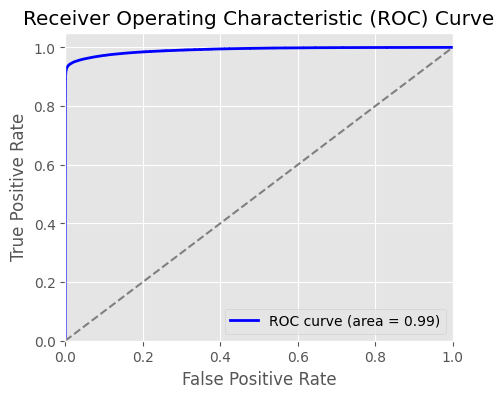

In [97]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = logreg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()